# 1. Libraries Imports

In [1]:
!pip install nrclex==3.0.0
!pip install transformers datasets scikit-learn torch -q
!pip install iterative-stratification -q
!pip install nltk tensorflow scikit-multilearn -q
!pip install krippendorff

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud, STOPWORDS
import spacy
from nrclex import NRCLex
import nltk
from transformers import pipeline
import random
import os
from sklearn.cluster import KMeans
import krippendorff
from sklearn.metrics import cohen_kappa_score

#For partions
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
import torch

#For Baseline Models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, hamming_loss, f1_score, accuracy_score)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

#CNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

#Bert
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch


In [3]:
def set_seed(seed=2026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 2. Document Import


Make sure you drag and drop the CSV on the left side so that you can run it without issues.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
rates_df = pd.read_csv("/content/drive/MyDrive/BigData_FinalProject/RateMyProfessor_Sample data.csv")
rates_df.head()

,professor_name,school_name,department_name,local_name,state_name,year_since_first_review,star_rating,take_again,diff_index,tag_professor,...,lots_of_homework,accessible_outside_class,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline
0,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11.0,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
1,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11.0,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
2,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11.0,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
3,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11.0,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
4,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11.0,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0


# 3. Data Preprocessing and Lemmatization - BaseLine Models

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Filtering comments (Important to run)

Filtering the Columns that we are not going to use for the project

In [8]:
columns_to_drop = ['school_name','local_name','state_name','year_since_first_review',
    'would_take_agains','take_again','tag_professor','post_date', 'name_onlines',
    'star_rating','diff_index', 'attence', 'for_credits', 'would_take_agains', 'grades',
    'help_useful', 'help_not_useful','gender', 'asian', 'hispanic', 'nh_black',
    'nh_white', 'name_not_onlines'
]

new_rates_df = rates_df.drop(columns=columns_to_drop)


From Give good feedback, those columns are One-Hot Encoding

There are some null comments on the dataset. Since our main focus will be the comments. We are going to eliminate them. For now there are 7 (no representa mas del 5% por lo tanto esta borrarlo)

In [9]:
null_comments_df = new_rates_df[new_rates_df['comments'].isnull()]
display(null_comments_df[['professor_name', 'department_name', 'comments']])

,professor_name,department_name,comments
126,Lauren Bold,Education department,NaN
693,Sharon Teague,History department,NaN
694,Sharon Teague,History department,NaN
695,Sharon Teague,History department,NaN
696,Sharon Teague,History department,NaN
697,Sharon Teague,History department,NaN
4185,Steven Schlossman,History department,NaN


In [10]:
new_rates_df = new_rates_df.dropna(subset=['comments']) #Remove Null comments

In [11]:
singlechar_comments_df = new_rates_df[new_rates_df['comments'].astype(str).str.len() <= 1]
display(singlechar_comments_df[['professor_name', 'department_name', 'comments']])

,professor_name,department_name,comments
474,Mima Petrovic,History department,.
3178,Susan Murray,Communication department,*
4372,Douglas Johansen,Marketing department,t
5950,McVey,Mathematics department,.
8727,Kevin Hanson,Film department,.
15559,Ioannis Psaromiligkos,Engineering department,-


In [12]:
indices_to_drop = singlechar_comments_df.index
new_rates_df = new_rates_df.drop(indices_to_drop) #Remove comments with just one character

Regular expresion that will be able to identify, two characters alfabetic next to each other, so that we can eliminates comments like '...', 'B!', '!!!'

In [13]:
regex_pattern = r'[a-zA-Z]{2,}'
new_rates_df = new_rates_df[
    new_rates_df['comments'].astype(str).str.contains(regex_pattern, na=False)
]

In [14]:
small_comments_df = new_rates_df[new_rates_df['comments'].astype(str).str.len() <= 3] #Remove comments with 3 or less characters
display(small_comments_df[['professor_name', 'department_name', 'comments']])

,professor_name,department_name,comments
455,Mima Petrovic,History department,No
1520,Desmond Hamlet,English department,bad
1863,Amin Ibrahim,Chemistry department,ok
3213,Joseph Fruscione,Writing department,Ehh
4709,Ed Giardina,Graphic Arts department,HOT
7553,Tyler Spalding,Engineering department,fun
10125,Paul Haynie,History department,ugh
14059,Markus Schneider,Computer Science department,gr8
14233,Azzam El-Shihabi,Engineering department,Uh!
18898,John Keating,Business department,meh


Looking at the result for small comments, line 14059 has 'gr8' which doesn't provide any significant information, so we eliminate it manually.


In [15]:
new_rates_df = new_rates_df.drop(14059)

In [16]:
new_rates_df.describe(include="object").T

,count,unique,top,freq
professor_name,19975,1413,Alan Bell,38
department_name,19975,101,English department,2259
comments,19975,18910,No Comments,967
race,19975,3,nh_white,11218


On the comments row we can see that the top frequency comes from 'No comments', which can be interpret as 'Neutral' or 'Not Emotional Informative'. Therefore, we are not going to used it for the analysis.

In [17]:
new_rates_df = new_rates_df[new_rates_df['comments'] != 'No Comments']

In [18]:
new_rates_df.describe(include="object").T

,count,unique,top,freq
professor_name,19008,1406,Alan Bell,36
department_name,19008,100,English department,2139
comments,19008,18909,Awesome!,5
race,19008,3,nh_white,10617


A total of 992 entries were eliminated. (Not too bad :))

## Cleaning and Normalizing the comments (No important for labeling)

### 1. Lowercasing the comments



In [19]:
new_rates_df['comments'] = new_rates_df['comments'].str.lower()

### 2. Removing Puntuation and unecesssary caracters

In [20]:
def clean_text(text):
    text = text.replace("-", " ")
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text


In [21]:
new_rates_df['comments_clean'] = new_rates_df['comments'].apply(clean_text)

In [22]:
new_rates_df = new_rates_df[new_rates_df['comments_clean'] != 'no comment']
new_rates_df = new_rates_df[new_rates_df['comments_clean'] != 'no comments']

In [23]:
new_rates_df['comments_clean']

,comments_clean
0,this class is hard but its a two in one gen ed...
1,definitely going to choose prof looneys class ...
2,i overall enjoyed this class because the assig...
3,yes its possible to get an a but youll definit...
4,professor looney has great knowledge in astron...
...,...
19995,great sense of humor love parasites now
19996,he is a really nice guy and is really funnyhow...
19997,his parasitology class is a lot of work but he...
19998,he is way too much work for a 1 credit class s...


### 3. Tokenization and Lemmatization

In [24]:
nlp = spacy.load("en_core_web_sm")

In [25]:
def tokenization_and_lemmatize(text):
    doc = nlp(text)
    lemmatized_text = " ".join([token.lemma_ for token in doc])
    return lemmatized_text

In [26]:
new_rates_df['comments_clean_lem'] = new_rates_df['comments_clean'].apply(tokenization_and_lemmatize)

In [27]:
print(new_rates_df[['comments', 'comments_clean']].head())

                                            comments  \
0  this class is hard, but its a two-in-one gen-e...   
1  definitely going to choose prof. looney\'s cla...   
2  i overall enjoyed this class because the assig...   
3  yes, it\'s possible to get an a but you\'ll de...   
4  professor looney has great knowledge in astron...   

                                      comments_clean  
0  this class is hard but its a two in one gen ed...  
1  definitely going to choose prof looneys class ...  
2  i overall enjoyed this class because the assig...  
3  yes its possible to get an a but youll definit...  
4  professor looney has great knowledge in astron...  


In [28]:
new_rates_df.to_csv("/content/drive/MyDrive/BigData_FinalProject/new_rates_cleaned.csv", index=False)

# $\color{red}{\mathbf{BEGIN\ FROM\ HERE\ WITH\ THE\ DATASET\ CLEAN}}$

In [33]:
clean_rates_df = pd.read_csv("/content/drive/MyDrive/BigData_FinalProject/new_rates_cleaned.csv")
clean_rates_df.head()

,professor_name,department_name,num_student,student_star,student_difficult,comments,word_comment,race,gives_good_feedback,caring,...,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline,comments_clean,comments_clean_lem
0,Leslie Looney,Astronomy department,26.0,5.0,3.0,"this class is hard, but its a two-in-one gen-e...",44.0,hispanic,1,0,...,0,0,0,1,0,0,0,0,this class is hard but its a two in one gen ed...,this class be hard but its a two in one gen ed...
1,Leslie Looney,Astronomy department,26.0,5.0,2.0,definitely going to choose prof. looney\'s cla...,38.0,hispanic,1,0,...,0,0,0,1,0,0,0,0,definitely going to choose prof looneys class ...,definitely go to choose prof looney class agai...
2,Leslie Looney,Astronomy department,26.0,4.0,3.0,i overall enjoyed this class because the assig...,32.0,hispanic,1,0,...,0,0,0,1,0,0,0,0,i overall enjoyed this class because the assig...,I overall enjoy this class because the assignm...
3,Leslie Looney,Astronomy department,26.0,5.0,3.0,"yes, it\'s possible to get an a but you\'ll de...",64.0,hispanic,1,0,...,0,0,0,1,0,0,0,0,yes its possible to get an a but youll definit...,yes its possible to get an a but you ll defini...
4,Leslie Looney,Astronomy department,26.0,5.0,1.0,professor looney has great knowledge in astron...,57.0,hispanic,1,0,...,0,0,0,1,0,0,0,0,professor looney has great knowledge in astron...,professor looney have great knowledge in astro...


Random Selected 10% of the data, which will be use for labeling and verification

In [34]:
sampled_df = clean_rates_df.sample(frac=0.1, random_state=42)

# 4. Emotional Labeling

## NRCLexicon (Only for demostration)

In [41]:
emotion_cols = ['anger','anticipation','disgust','fear','joy','sadness','surprise','trust']

In [42]:
negation_words = ['not','no','never','cannot','none','nobody']

def get_emotions_with_negation(text):
    words = text.split()
    emotion_scores = {}
    negate = False
    window = 0
    for word in words:
        word_lower = word.lower()

        if word_lower in negation_words:
            negate = True
            window = 3
            continue

        nrc = NRCLex(word_lower)
        for emo, count in nrc.raw_emotion_scores.items():
            if emo in emotion_cols:
                if negate:
                    if emo in ['joy','trust','anticipation']:
                        emo = 'sadness'
                    window -= 1
                    if window <= 0:
                        negate = False

                emotion_scores[emo] = emotion_scores.get(emo,0) + count

    return emotion_scores

In [43]:
sampled_df['emotion_scores'] = sampled_df['comments_clean_lem'].apply(get_emotions_with_negation)

In [44]:
def dominant_emotion_with_ties(row):
    scores = row['emotion_scores']
    if not scores:
        return None

    max_score = max(scores.values())
    if max_score == 0:
        return None

    dominant = [emo for emo, val in scores.items() if val == max_score]

    return ','.join(dominant)

In [45]:
sampled_df['dominant_emotion'] = sampled_df.apply(dominant_emotion_with_ties, axis=1)

In [46]:
sampled_df.to_csv(
    "/content/drive/MyDrive/BigData_FinalProject/emotional_label_rates_NrcLexicon.csv",
    index=False
)

## Zero-Shot Testing

In [47]:
comments = sampled_df['comments'].tolist()

We are going to pipeline the comments using the "facebook/bart-large-mnli" model

In [48]:
teacher = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0) # Use device=0 for GPU if available

results_list = []
batch_size = 32

for i in range(0, len(comments), batch_size):
    batch_comments = comments[i:i + batch_size]
    batch_results = teacher(batch_comments, emotion_cols , multi_label=True)

    for text, result in zip(batch_comments, batch_results):
        top_three_labels = result['labels'][0:3]
        top_three_confidences = result['scores'][0:3]

        results_list.append({
            "text": text,
            "top_labels": top_three_labels,
            "top_confidences": top_three_confidences
        })

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [49]:
df_results_zero_shot = pd.DataFrame(results_list)

df_results_zero_shot.head()

,text,top_labels,top_confidences
0,doesn\'t assign too much homework but tests ar...,"[trust, anticipation, surprise]","[0.25402459502220154, 0.16723185777664185, 0.1..."
1,very professional instructor. very knowledgeab...,"[trust, anticipation, joy]","[0.7527748942375183, 0.5771164298057556, 0.397..."
2,the tests on his class is in class had writing...,"[surprise, disgust, anger]","[0.9832528233528137, 0.8987607955932617, 0.691..."
3,patient and always provided extra information ...,"[anticipation, surprise, trust]","[0.5813106894493103, 0.1306028962135315, 0.092..."
4,took him for only lecture. he is intimidating ...,"[surprise, trust, fear]","[0.7094601988792419, 0.3366815447807312, 0.332..."


In [50]:
df_results_zero_shot.to_csv(
    "/content/drive/MyDrive/BigData_FinalProject/df_results_zero_shot.csv",
    index=False
)

## Test GoEmotions Model

In [51]:
classifier = pipeline("text-classification",
                      model="SamLowe/roberta-base-go_emotions",
                      top_k=None,
                      device=0)

results_goEmotions = classifier(comments, truncation=True)

final_labels = []

for i, prediction_list in enumerate(results_goEmotions):

    sorted_preds = sorted(prediction_list, key=lambda x: x['score'], reverse=True)
    top_3 = sorted_preds[:3]
    labels_only = ", ".join([p['label'] for p in top_3])
    scores_only = ", ".join([f"{round(p['score'] * 100, 2)}%" for p in top_3])

    final_labels.append({
        "text": comments[i],
        "emotions": labels_only,
        "scores": scores_only
    })


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [52]:
df_results_go_emotions = pd.DataFrame(final_labels)
df_results_go_emotions

,text,emotions,scores
0,doesn\'t assign too much homework but tests ar...,"neutral, disapproval, approval","76.57%, 11.87%, 9.14%"
1,very professional instructor. very knowledgeab...,"admiration, approval, gratitude","88.81%, 13.52%, 6.55%"
2,the tests on his class is in class had writing...,"confusion, neutral, curiosity","75.74%, 29.76%, 20.11%"
3,patient and always provided extra information ...,"admiration, approval, neutral","90.56%, 12.51%, 4.37%"
4,took him for only lecture. he is intimidating ...,"admiration, neutral, approval","50.65%, 43.83%, 19.82%"
...,...,...,...
1895,"if you miss a class, make it up. do not wait t...","neutral, caring, approval","78.34%, 24.4%, 5.12%"
1896,fred is the best! i have to disagree with whoe...,"disapproval, approval, admiration","73.65%, 24.62%, 13.55%"
1897,i want to be just like kowalka!! he is a great...,"admiration, desire, approval","91.86%, 22.13%, 7.69%"
1898,"she\'s nice enough, goes over a lot examples, ...","annoyance, anger, disapproval","44.95%, 41.01%, 9.83%"


In [53]:
df_results_go_emotions.to_csv(
    "/content/drive/MyDrive/BigData_FinalProject/df_results_go_emotions.csv",
    index=False
)

## Joining together the models

In [54]:
nrclex_results_df = sampled_df[['comments', 'dominant_emotion']].copy()
nrclex_results_df.head()

,comments,dominant_emotion
13813,doesn\'t assign too much homework but tests ar...,"fear,sadness"
4097,very professional instructor. very knowledgeab...,trust
12527,the tests on his class is in class had writing...,"surprise,sadness"
16950,patient and always provided extra information ...,"anticipation,trust,disgust,sadness"
12544,took him for only lecture. he is intimidating ...,sadness


In [55]:
zero_shot_results_df = df_results_zero_shot[['text', 'top_labels', 'top_confidences']].copy()
zero_shot_results_df = zero_shot_results_df.rename(columns={'text': 'comments',
                                                            'top_labels': 'emotions_zero_shot',
                                                            'top_confidences': 'scores_zero_shot'})

In [56]:
def format_scores_as_percentages(scores_list):
    if not isinstance(scores_list, list):
        try:
            scores_list = eval(scores_list)
        except (SyntaxError, TypeError):
            return None

    formatted_scores = []
    for score in scores_list:
        percentage = round(score * 100, 2)
        formatted_scores.append(f"{percentage}%")
    return ', '.join(formatted_scores)

def format_emotions_zero_shot(emotion_list):
  return ", ".join(emotion_list)


zero_shot_results_df['scores_zero_shot'] = zero_shot_results_df['scores_zero_shot'].apply(format_scores_as_percentages)
zero_shot_results_df['emotions_zero_shot'] = zero_shot_results_df['emotions_zero_shot'].apply(format_emotions_zero_shot)
zero_shot_results_df.head()

,comments,emotions_zero_shot,scores_zero_shot
0,doesn\'t assign too much homework but tests ar...,"trust, anticipation, surprise","25.4%, 16.72%, 11.49%"
1,very professional instructor. very knowledgeab...,"trust, anticipation, joy","75.28%, 57.71%, 39.76%"
2,the tests on his class is in class had writing...,"surprise, disgust, anger","98.33%, 89.88%, 69.2%"
3,patient and always provided extra information ...,"anticipation, surprise, trust","58.13%, 13.06%, 9.26%"
4,took him for only lecture. he is intimidating ...,"surprise, trust, fear","70.95%, 33.67%, 33.26%"


In [57]:
go_emotions_results_df = df_results_go_emotions[['text', 'emotions', 'scores']].copy()
go_emotions_results_df = go_emotions_results_df.rename(columns={'text': 'comments',
                                                                'emotions': 'emotions_go_emotions',
                                                                'scores': 'scores_go_emotions'})
go_emotions_results_df.head()

,comments,emotions_go_emotions,scores_go_emotions
0,doesn\'t assign too much homework but tests ar...,"neutral, disapproval, approval","76.57%, 11.87%, 9.14%"
1,very professional instructor. very knowledgeab...,"admiration, approval, gratitude","88.81%, 13.52%, 6.55%"
2,the tests on his class is in class had writing...,"confusion, neutral, curiosity","75.74%, 29.76%, 20.11%"
3,patient and always provided extra information ...,"admiration, approval, neutral","90.56%, 12.51%, 4.37%"
4,took him for only lecture. he is intimidating ...,"admiration, neutral, approval","50.65%, 43.83%, 19.82%"


In [58]:
combined_emotion_results_df = nrclex_results_df.merge(zero_shot_results_df, on='comments', how='left')
combined_emotion_results_df = combined_emotion_results_df.merge(go_emotions_results_df, on='comments', how='left')
combined_emotion_results_df.head()

,comments,dominant_emotion,emotions_zero_shot,scores_zero_shot,emotions_go_emotions,scores_go_emotions
0,doesn\'t assign too much homework but tests ar...,"fear,sadness","trust, anticipation, surprise","25.4%, 16.72%, 11.49%","neutral, disapproval, approval","76.57%, 11.87%, 9.14%"
1,very professional instructor. very knowledgeab...,trust,"trust, anticipation, joy","75.28%, 57.71%, 39.76%","admiration, approval, gratitude","88.81%, 13.52%, 6.55%"
2,the tests on his class is in class had writing...,"surprise,sadness","surprise, disgust, anger","98.33%, 89.88%, 69.2%","confusion, neutral, curiosity","75.74%, 29.76%, 20.11%"
3,patient and always provided extra information ...,"anticipation,trust,disgust,sadness","anticipation, surprise, trust","58.13%, 13.06%, 9.26%","admiration, approval, neutral","90.56%, 12.51%, 4.37%"
4,took him for only lecture. he is intimidating ...,sadness,"surprise, trust, fear","70.95%, 33.67%, 33.26%","admiration, neutral, approval","50.65%, 43.83%, 19.82%"


In [59]:
combined_emotion_results_df.to_csv(
    "/content/drive/MyDrive/BigData_FinalProject/combined_emotion_results_df.csv",
    index=False
)

# $\color{red}{\mathbf{BEGIN\ FROM\ HERE\ AFTER\ DATA\ ANOTATION}}$

After we did the emotional labeling, we proceeded to do manual annotations which will be imported for the following steps.

In [61]:
manual_review = pd.read_excel("/content/drive/MyDrive/BigData_FinalProject/manual_review_df.xlsx", sheet_name="manual_review_df")
manual_review = manual_review.dropna(subset=['comments', 'claude_emotion'])
manual_review.head()

,comments,NRCLexicon_emotion,emotions_zero_shot,scores_zero_shot,emotions_go_emotions,scores_go_emotions,Human Emotion,claude_emotion
0,doesn\'t assign too much homework but tests ar...,"fear,sadness","trust, anticipation, surprise","25.4%, 16.72%, 11.49%","neutral, disapproval, approval","76.57%, 11.87%, 9.14%",vulnerability,approval
1,very professional instructor. very knowledgeab...,trust,"trust, anticipation, joy","75.28%, 57.71%, 39.76%","admiration, approval, gratitude","88.81%, 13.52%, 6.55%",approval,"approval, gratitude"
2,the tests on his class is in class had writing...,"surprise,sadness","surprise, disgust, anger","98.33%, 89.88%, 69.2%","confusion, neutral, curiosity","75.74%, 29.76%, 20.11%",vulnerability,"disapproval, annoyance"
3,patient and always provided extra information ...,"anticipation,trust,disgust,sadness","anticipation, surprise, trust","58.13%, 13.06%, 9.26%","admiration, approval, neutral","90.56%, 12.51%, 4.37%",gratitude,"approval, gratitude"
4,took him for only lecture. he is intimidating ...,sadness,"surprise, trust, fear","70.95%, 33.67%, 33.26%","admiration, neutral, approval","50.65%, 43.83%, 19.82%",approval,"approval, annoyance"


# 5. Inter Annotation Agreement Calculation

In [186]:
annotators_review = pd.read_excel("/content/drive/MyDrive/BigData_FinalProject/manual_review_df.xlsx", sheet_name="Inner Annotation Review")

In [187]:
cols = [
    "primary_annotator_emotion",
    "annotator1_emotion",
    "annotator2_emotion",
    "annotator3_emotion"
]

In [189]:
annotators_review = annotators_review.rename(columns={'annotator1_emotion': 'annotator1', 'annotator2_emotion': 'annotator2', 'annotator3_emotion': 'annotator3'})

In [190]:
emotions = ['approval','joy','gratitude','annoyance','disapproval', 'vulnerability']

In [191]:
for emotion in emotions:
    for annotator in ['annotator1','annotator2','annotator3']:
        annotators_review[f'{annotator}_{emotion}'] = annotators_review[annotator].apply(
            lambda x: 1 if emotion in [e.strip() for e in x.split(',')] else 0
        )

## Krippendorff's alpha

In [194]:
results = {}


for emotion in emotions:
    matrix = annotators_review[[f'annotator1_{emotion}', f'annotator2_{emotion}', f'annotator3_{emotion}']].to_numpy().T
    if len(np.unique(matrix)) > 1:
      alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='nominal')
    else:
      alpha = None

    results[emotion] = alpha

In [195]:
df_alpha = pd.DataFrame(list(results.items()), columns=["emotion", "alpha"]).dropna()
df_alpha = df_alpha.sort_values(by="alpha", ascending=False)

print(df_alpha)

         emotion     alpha
4    disapproval  0.627907
0       approval  0.623280
2      gratitude  0.492570
5  vulnerability  0.412174
3      annoyance  0.387211
1            joy  0.253704


In [196]:
overall_alpha = df_alpha['alpha'].mean()
print("Average Krippendorff's alpha:", overall_alpha)

Average Krippendorff's alpha: 0.4661410961655423


In [199]:
results = {}

annotator_pairs = [('annotator1','annotator2'),
                   ('annotator1','annotator3'),
                   ('annotator2','annotator3')]

results = {pair: {} for pair in annotator_pairs}

for emotion in emotions:
    for annotator in ['annotator1','annotator2','annotator3']:
        annotators_review[f'{annotator}_{emotion}'] = annotators_review[annotator].apply(
            lambda x: 1 if x.split(',')[0].strip() == emotion else 0
        )

    for a1, a2 in annotator_pairs:
        kappa = cohen_kappa_score(
            annotators_review[f'{a1}_{emotion}'],
            annotators_review[f'{a2}_{emotion}']
        )
        results[(a1,a2)][emotion] = kappa

df_pairs = pd.DataFrame(results)
df_pairs.index.name = 'emotion'
df_pairs = df_pairs.sort_index()

print(df_pairs)

              annotator1            annotator2
              annotator2 annotator3 annotator3
emotion                                       
annoyance       0.347154   0.290682   0.502945
approval        0.591500   0.584783   0.717502
disapproval     0.537376   0.511743   0.608703
gratitude       0.460693   0.251746   0.291609
joy             0.216449   0.330160   0.449279
vulnerability   0.532092   0.432561   0.744993


# 6. Data Partition

In [62]:
emotions = ['annoyance', 'approval', 'disapproval', 'gratitude', 'joy', 'vulnerability']

In [63]:
df = manual_review.copy()
df['emotion_list'] = df['claude_emotion'].apply(
    lambda x: [e.strip() for e in str(x).split(',')]
)

mlb = MultiLabelBinarizer(classes=emotions)
Y   = mlb.fit_transform(df['emotion_list'])

In [64]:
print(f"Y shape: {Y.shape}")
print(f"\nSanity check:")
print(pd.DataFrame(Y, columns=emotions).head(10))

Y shape: (1905, 6)

Sanity check:
   annoyance  approval  disapproval  gratitude  joy  vulnerability
0          0         1            0          0    0              0
1          0         1            0          1    0              0
2          1         0            1          0    0              0
3          0         1            0          1    0              0
4          1         1            0          0    0              0
5          0         1            0          0    1              0
6          0         1            0          0    0              0
7          0         1            0          0    0              0
8          0         1            0          0    0              0
9          1         0            1          0    0              0


In [65]:
emotion_counts = pd.Series(Y.sum(axis=0), index=emotions).sort_values(ascending=False)
emotion_pct    = emotion_counts / len(Y) * 100
print("Emotion Distribution:")
print(f"{'Emotion':<20} {'Count':>8} {'% of comments':>15}")
print("-" * 45)
for emotion, count in emotion_counts.items():
    print(f"{emotion:<20} {int(count):>8} {emotion_pct[emotion]:>14.2f}%")
print(f"\nTotal comments:        {len(Y)}")
print(f"Total label instances: {int(Y.sum())}")
print(f"Avg labels per comment:{Y.sum(axis=1).mean():.2f}")


Emotion Distribution:
Emotion                 Count   % of comments
---------------------------------------------
approval                 1255          65.88%
disapproval               590          30.97%
annoyance                 322          16.90%
joy                       173           9.08%
gratitude                 164           8.61%
vulnerability              38           1.99%

Total comments:        1905
Total label instances: 2542
Avg labels per comment:1.33


In [66]:
combo_counts = {}
for row in Y:
    labels = tuple(sorted([emotions[i] for i, v in enumerate(row) if v == 1]))
    combo_counts[labels] = combo_counts.get(labels, 0) + 1

combo_df = pd.DataFrame([
    {"combination": " + ".join(c), "count": n, "pct": n/len(Y)*100}
    for c, n in sorted(combo_counts.items(), key=lambda x: -x[1])
])
print(f"\nAll combinations:")
print(combo_df.to_string(index=False))


All combinations:
                combination  count       pct
                   approval    982 51.548556
    annoyance + disapproval    303 15.905512
                disapproval    255 13.385827
             approval + joy    139  7.296588
       approval + gratitude    127  6.666667
disapproval + vulnerability     32  1.679790
            gratitude + joy     29  1.522310
                  annoyance     12  0.629921
                  gratitude      8  0.419948
       annoyance + approval      7  0.367454
              vulnerability      6  0.314961
                        joy      5  0.262467


## Split into Train, Validation, Test

In [67]:
manual_review['label_list'] = manual_review['claude_emotion'].apply(
    lambda x: [e.strip() for e in x.split(',')]
)

In [68]:
emotion2id = {e: i for i, e in enumerate(emotions)}
emotion2id

{'annoyance': 0,
 'approval': 1,
 'disapproval': 2,
 'gratitude': 3,
 'joy': 4,
 'vulnerability': 5}

In [69]:
def encode_labels(text):
    vec = np.zeros(len(emotions))
    for e in text.split(','):
        vec[emotion2id[e.strip()]] = 1
    return vec

manual_review['labels'] = manual_review['claude_emotion'].apply(encode_labels)

In [70]:
X = manual_review["comments"].values
y = np.vstack(manual_review["labels"].values)

### Split (65/15/20)

In [71]:
# Test split (20%)
msss_test = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)
train_val_idx, test_idx = next(msss_test.split(X, y))

In [72]:
# Val split (15% total)
msss_val = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.1875, random_state=42
)
train_idx, val_idx = next(msss_val.split(X[train_val_idx], y[train_val_idx]))

In [73]:
X_train = X[train_val_idx][train_idx]
X_val   = X[train_val_idx][val_idx]
X_test  = X[test_idx]

y_train = y[train_val_idx][train_idx]
y_val   = y[train_val_idx][val_idx]
y_test  = y[test_idx]

In [74]:
def label_distribution(y_split, name, emotions):
    freq = y_split.mean(axis=0)
    print(f"\n── {name} (n={len(y_split)}) ──")
    for e, f in zip(emotions, freq):
        print(f"{e:<15}: {f:.3f}")

label_distribution(y_train, "Train", emotions)
label_distribution(y_val,   "Val",   emotions)
label_distribution(y_test,  "Test",  emotions)


── Train (n=1234) ──
annoyance      : 0.170
approval       : 0.661
disapproval    : 0.310
gratitude      : 0.086
joy            : 0.091
vulnerability  : 0.019

── Val (n=285) ──
annoyance      : 0.168
approval       : 0.660
disapproval    : 0.312
gratitude      : 0.088
joy            : 0.091
vulnerability  : 0.021

── Test (n=386) ──
annoyance      : 0.166
approval       : 0.650
disapproval    : 0.306
gratitude      : 0.085
joy            : 0.091
vulnerability  : 0.021


In [75]:
mlb = MultiLabelBinarizer(classes=emotions)
mlb.fit([emotions])  # ensure consistent order

# Convert back to list format if needed
def decode_labels(y_row):
    return [emotions[i] for i, v in enumerate(y_row) if v == 1]

Y_train_mlb = y_train
Y_val_mlb   = y_val
Y_test_mlb  = y_test

In [76]:
y_train_list = [decode_labels(row) for row in y_train]

### Sanity check: label distribution across splits

In [77]:
print("\nLabel prevalence per split (should be similar across all three):")
print(f"{'Emotion':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 46)
for i, emotion in enumerate(emotions):
    train_pct = y_train[:, i].mean() * 100
    val_pct   = y_val[:, i].mean()   * 100
    test_pct  = y_test[:, i].mean()  * 100
    print(f"{emotion:<20} {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")


Label prevalence per split (should be similar across all three):
Emotion                 Train      Val     Test
----------------------------------------------
annoyance               17.0%    16.8%    16.6%
approval                66.1%    66.0%    65.0%
disapproval             31.0%    31.2%    30.6%
gratitude                8.6%     8.8%     8.5%
joy                      9.1%     9.1%     9.1%
vulnerability            1.9%     2.1%     2.1%


In [78]:
print("Absolute label counts per split:")
print(f"{'Emotion':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
print("-" * 58)
for i, emotion in enumerate(emotions):
    tr = y_train[:, i].sum()
    va = y_val[:, i].sum()
    te = y_test[:, i].sum()
    print(f"{emotion:<20} {tr:>8} {va:>8} {te:>8}  {tr+va+te:>8}")

Absolute label counts per split:
Emotion                 Train      Val     Test     Total
----------------------------------------------------------
annoyance               210.0     48.0     64.0     322.0
approval                816.0    188.0    251.0    1255.0
disapproval             383.0     89.0    118.0     590.0
gratitude               106.0     25.0     33.0     164.0
joy                     112.0     26.0     35.0     173.0
vulnerability            24.0      6.0      8.0      38.0


Because of the imbalance distribution among the emotions, we proceed to do a weight analysis in the loss function.

In [79]:
pos_weights = []
for i in range(y_train.shape[1]):
    pos = y_train[:, i].sum()
    neg = len(y_train) - pos
    pos_weights.append(neg / pos)

pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float)
print("Positive weights per label:")
for emotion, w in zip(emotions, pos_weights):
    print(f"  {emotion:<20} {w:.1f}x")

Positive weights per label:
  annoyance            4.9x
  approval             0.5x
  disapproval          2.2x
  gratitude            10.6x
  joy                  10.0x
  vulnerability        50.4x


# 7. Baseline Models

In [206]:
def evaluate(model_name, Y_true, Y_pred, label_names):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Micro F1: {f1_score(Y_true, Y_pred, average='micro'):.4f}")
    print(f"  Macro F1: {f1_score(Y_true, Y_pred, average='macro'):.4f}")
    print(f"\n  Per-label F1:")
    per_label = f1_score(Y_true, Y_pred, average=None)
    for label, score in zip(label_names, per_label):
        bar = '█' * int(score * 20)
        print(f"  {label:<20} {score:.4f}  {bar}")

## Inital Training

### TF-IDF vectorizer (shared by LR and SVM)

In [207]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (1234, 6701)


### Logistic Regression

In [208]:
lr_model = OneVsRestClassifier(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=1.0,
        solver='lbfgs'
    )
)

lr_model.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000))

In [209]:
# Validation
lr_val_pred = lr_model.predict(X_val_tfidf)
evaluate("Logistic Regression — Validation", y_val, lr_val_pred, emotions)


  Logistic Regression — Validation
  Micro F1: 0.7513
  Macro F1: 0.5216

  Per-label F1:
  approval             0.6545  █████████████
  joy                  0.8798  █████████████████
  gratitude            0.7872  ███████████████
  annoyance            0.3929  ███████
  disapproval          0.4151  ████████
  vulnerability        0.0000  


In [210]:
# Test
lr_test_pred = lr_model.predict(X_test_tfidf)
evaluate("Logistic Regression — Test", y_test, lr_test_pred, emotions)


  Logistic Regression — Test
  Micro F1: 0.7371
  Macro F1: 0.5317

  Per-label F1:
  approval             0.4706  █████████
  joy                  0.8618  █████████████████
  gratitude            0.7674  ███████████████
  annoyance            0.5625  ███████████
  disapproval          0.5278  ██████████
  vulnerability        0.0000  


### SVM

In [211]:
svm_model = OneVsRestClassifier(
    SVC(
        kernel='linear',
        class_weight='balanced',
        C=1.0,
        probability=False
    )
)
svm_model.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=SVC(class_weight='balanced', kernel='linear'))

In [212]:
# Validation
svm_val_pred = svm_model.predict(X_val_tfidf)
evaluate("SVM — Validation", y_val, svm_val_pred, emotions)


  SVM — Validation
  Micro F1: 0.7510
  Macro F1: 0.4907

  Per-label F1:
  approval             0.6139  ████████████
  joy                  0.8760  █████████████████
  gratitude            0.7845  ███████████████
  annoyance            0.3590  ███████
  disapproval          0.3111  ██████
  vulnerability        0.0000  


In [213]:
# Test
svm_test_pred = svm_model.predict(X_test_tfidf)
evaluate("SVM — Test", y_test, svm_test_pred, emotions)


  SVM — Test
  Micro F1: 0.7267
  Macro F1: 0.4858

  Per-label F1:
  approval             0.4298  ████████
  joy                  0.8571  █████████████████
  gratitude            0.7578  ███████████████
  annoyance            0.4490  ████████
  disapproval          0.4211  ████████
  vulnerability        0.0000  


### CNN

In [214]:
MAX_VOCAB  = 10000
MAX_LEN    = 128
EMBED_DIM  = 100

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

def encode(texts):
    seqs = keras_tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

print(f"Encoded train shape: {X_train_seq.shape}")


pos_weights = []
for i in range(y_train.shape[1]):
    pos = y_train[:, i].sum()
    neg = len(y_train) - pos
    pos_weights.append(neg / pos)

pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float)
print("\nPositive weights per label:")
for emotion, w in zip(emotions, pos_weights):
    print(f"  {emotion:<20} {w:.1f}x")


class MultiLabelDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.tensor(sequences, dtype=torch.long)
        self.Y = torch.tensor(labels,    dtype=torch.float)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = MultiLabelDataset(X_train_seq, y_train)
val_ds   = MultiLabelDataset(X_val_seq,   y_val)
test_ds  = MultiLabelDataset(X_test_seq,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)


class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_labels,
                 num_filters=128, kernel_sizes=[2, 3, 4]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            c = c.max(dim=2).values
            pooled.append(c)
        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

cnn_model = TextCNN(
    vocab_size  = MAX_VOCAB + 1,
    embed_dim   = EMBED_DIM,
    num_labels  = len(emotions)
).to(device)

loss_fn   = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor.to(device))
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)


EPOCHS        = 10
THRESHOLD     = 0.5     # sigmoid threshold for positive prediction
best_val_f1   = 0
best_model_path = '/content/drive/MyDrive/BigData_FinalProject/best_cnn_model.pt'

for epoch in range(EPOCHS):
    # Train
    cnn_model.train()
    total_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        logits = cnn_model(X_batch)
        loss   = loss_fn(logits, Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validate
    cnn_model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            logits = cnn_model(X_batch.to(device))
            probs  = torch.sigmoid(logits).cpu().numpy()
            val_preds.append((probs >= THRESHOLD).astype(int))
            val_true.append(Y_batch.numpy())

    val_preds = np.vstack(val_preds)
    val_true  = np.vstack(val_true)

    val_micro = f1_score(val_true, val_preds, average='micro', zero_division=0)
    val_macro = f1_score(val_true, val_preds, average='macro', zero_division=0)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Micro F1: {val_micro:.4f} | Val Macro F1: {val_macro:.4f}")

    if val_macro > best_val_f1:
        best_val_f1 = val_macro
        torch.save(cnn_model.state_dict(), best_model_path)
        print(f"           ✓ Best model saved (Macro F1: {val_macro:.4f})")

Encoded train shape: (1234, 128)

Positive weights per label:
  approval             4.9x
  joy                  0.5x
  gratitude            2.2x
  annoyance            10.6x
  disapproval          10.0x
  vulnerability        50.4x

Using device: cuda
Epoch 01/10 | Loss: 1.1427 | Val Micro F1: 0.3105 | Val Macro F1: 0.2395
           ✓ Best model saved (Macro F1: 0.2395)
Epoch 02/10 | Loss: 0.9090 | Val Micro F1: 0.4493 | Val Macro F1: 0.3605
           ✓ Best model saved (Macro F1: 0.3605)
Epoch 03/10 | Loss: 0.7707 | Val Micro F1: 0.6304 | Val Macro F1: 0.4247
           ✓ Best model saved (Macro F1: 0.4247)
Epoch 04/10 | Loss: 0.6339 | Val Micro F1: 0.6577 | Val Macro F1: 0.4634
           ✓ Best model saved (Macro F1: 0.4634)
Epoch 05/10 | Loss: 0.5390 | Val Micro F1: 0.5917 | Val Macro F1: 0.4262
Epoch 06/10 | Loss: 0.4774 | Val Micro F1: 0.6984 | Val Macro F1: 0.4822
           ✓ Best model saved (Macro F1: 0.4822)
Epoch 07/10 | Loss: 0.3882 | Val Micro F1: 0.6898 | Val Macro F1

In [215]:
# ── 4f. Test evaluation with best model ───────────────────────────────────────
cnn_model.load_state_dict(torch.load(best_model_path))
cnn_model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        logits = cnn_model(X_batch.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        test_preds.append((probs >= THRESHOLD).astype(int))
        test_true.append(Y_batch.numpy())

test_preds = np.vstack(test_preds)
test_true  = np.vstack(test_true)

evaluate("CNN — Test", test_true, test_preds, emotions)


  CNN — Test
  Micro F1: 0.6324
  Macro F1: 0.4339

  Per-label F1:
  approval             0.4246  ████████
  joy                  0.7898  ███████████████
  gratitude            0.6596  █████████████
  annoyance            0.3636  ███████
  disapproval          0.3659  ███████
  vulnerability        0.0000  


### Performance excluding **vulnerability**

In [216]:
emotion_indices = {e: i for i, e in enumerate(emotions)}
exclude = ['vulnerability']
include_idx = [i for i, e in enumerate(emotions) if e not in exclude]

print("Macro F1 excluding vulnerability:")
for name, preds in [('LR', lr_test_pred),
                     ('SVM', svm_test_pred),
                     ('CNN', test_preds)]:
    score = f1_score(
        y_test[:, include_idx],
        preds[:, include_idx],
        average='macro',
        zero_division=0
    )
    print(f"  {name}: {score:.4f}")

Macro F1 excluding vulnerability:
  LR: 0.6380
  SVM: 0.5829
  CNN: 0.5207


## Hyperparameter tuning

### Logistic Regression

In [217]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   OneVsRestClassifier(
        LogisticRegression(class_weight='balanced',
                           max_iter=1000, solver='lbfgs')
    ))
])

lr_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2), (1, 3)],
    'tfidf__min_df':       [1, 2],
    'clf__estimator__C':   [0.1, 1.0, 10.0],
}

lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    scoring='f1_macro', cv=3,
    n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train[:, include_idx])

print("Best LR params:", lr_grid.best_params_)
print(f"Best LR CV Macro F1: {lr_grid.best_score_:.4f}")

lr_tuned_pred = lr_grid.best_estimator_.predict(X_test)
lr_tuned_score = f1_score(
    y_test[:, include_idx], lr_tuned_pred,
    average='macro', zero_division=0
)
print(f"Tuned LR Test Macro F1 (excl. vulnerability): {lr_tuned_score:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best LR params: {'clf__estimator__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best LR CV Macro F1: 0.5923
Tuned LR Test Macro F1 (excl. vulnerability): 0.5995


### SVM

In [218]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   OneVsRestClassifier(
        SVC(kernel='linear', class_weight='balanced', probability=True)
    ))
])

svm_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'tfidf__min_df':       [1, 2],
    'clf__estimator__C':   [0.1, 1.0, 10.0],
}

svm_grid = GridSearchCV(
    svm_pipeline, svm_param_grid,
    scoring='f1_macro', cv=3,
    n_jobs=-1, verbose=1
)
svm_grid.fit(X_train, y_train[:, include_idx])

print("\nBest SVM params:", svm_grid.best_params_)
print(f"Best SVM CV Macro F1: {svm_grid.best_score_:.4f}")

svm_tuned_pred = svm_grid.best_estimator_.predict(X_test)
svm_tuned_score = f1_score(
    y_test[:, include_idx], svm_tuned_pred,
    average='macro', zero_division=0
)
print(f"Tuned SVM Test Macro F1 (excl. vulnerability): {svm_tuned_score:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best SVM params: {'clf__estimator__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best SVM CV Macro F1: 0.5662
Tuned SVM Test Macro F1 (excl. vulnerability): 0.5973


##  Per-label threshold tuning

In [219]:
def tune_thresholds_sklearn(model, X_val, Y_val, emotions, include_idx, custom = False):
    """Tune decision threshold per label using validation set probabilities."""
    if custom:
      val_probs  = model
    else:
      val_probs  = model.predict_proba(X_val)   # shape: (n_samples, n_labels)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_thresholds = []

    print(f"{'Emotion':<20} {'Threshold':>10} {'Val F1':>10}")
    print("-" * 42)
    for i, emotion in enumerate(emotions):
        best_t, best_f1 = 0.5, 0
        for t in thresholds:
            preds = (val_probs[:, i] >= t).astype(int)
            score = f1_score(
                Y_val[:, include_idx[i]], preds,
                average='binary', zero_division=0
            )
            if score > best_f1:
                best_f1, best_t = score, t
        best_thresholds.append(best_t)
        print(f"{emotion:<20} {best_t:>10.2f} {best_f1:>10.4f}")

    return np.array(best_thresholds)

### LR

In [220]:
# Get validation probabilities and tune thresholds
X_val_tfidf_lr  = lr_grid.best_estimator_.named_steps['tfidf'].transform(X_val)
X_test_tfidf_lr = lr_grid.best_estimator_.named_steps['tfidf'].transform(X_test)

print("LR threshold tuning:")
lr_thresholds = tune_thresholds_sklearn(
    lr_grid.best_estimator_.named_steps['clf'],
    X_val_tfidf_lr, y_val[:, include_idx],
    [e for e in emotions if e != 'vulnerability'], include_idx
)

# Apply tuned thresholds on test
lr_val_probs  = lr_grid.best_estimator_.predict_proba(X_val)
lr_test_probs = lr_grid.best_estimator_.predict_proba(X_test)
lr_thresh_pred = (lr_test_probs >= lr_thresholds).astype(int)

lr_thresh_score = f1_score(
    y_test[:, include_idx], lr_thresh_pred,
    average='macro', zero_division=0
)
print(f"\nLR + tuned thresholds Test Macro F1: {lr_thresh_score:.4f}")

LR threshold tuning:
Emotion               Threshold     Val F1
------------------------------------------
approval                   0.50     0.6412
joy                        0.50     0.8619
gratitude                  0.50     0.7755
annoyance                  0.55     0.3810
disapproval                0.50     0.4571

LR + tuned thresholds Test Macro F1: 0.6007


### SVM

In [221]:
print(svm_grid.best_estimator_.named_steps['clf'].estimator.probability)

True


In [222]:
svm_val_probs  = svm_grid.best_estimator_.predict_proba(X_val)
svm_test_probs = svm_grid.best_estimator_.predict_proba(X_test)

print("SVM threshold tuning:")
svm_threshold_array = tune_thresholds_sklearn(
    svm_grid.best_estimator_,
    X_val, y_val[:, include_idx],
    [e for e in emotions if e != 'vulnerability'], include_idx
)

svm_thresh_pred = (svm_test_probs >= svm_threshold_array).astype(int)

svm_thresh_score = f1_score(
    y_test[:, include_idx], svm_thresh_pred,
    average='macro', zero_division=0
)
svm_thresh_micro = f1_score(
    y_test[:, include_idx], svm_thresh_pred,
    average='micro', zero_division=0
)


print(f"\nSVM + tuned thresholds Test Macro F1: {svm_thresh_score:.4f}")

SVM threshold tuning:
Emotion               Threshold     Val F1
------------------------------------------
approval                   0.25     0.6357
joy                        0.50     0.8792
gratitude                  0.35     0.7670
annoyance                  0.35     0.4348
disapproval                0.20     0.4688

SVM + tuned thresholds Test Macro F1: 0.6171


## GloVe pretrained embeddings for CNN

In [223]:
# Download GloVe
if not os.path.exists('/content/glove.6B.100d.txt'):
    !wget -q https://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -q /content/glove.6B.zip -d /content/
    print("GloVe downloaded")

In [224]:
# Build embedding matrix
EMBED_DIM = 100
glove_embeddings = {}
with open('/content/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        glove_embeddings[values[0]] = np.asarray(values[1:], dtype='float32')

word_index       = keras_tokenizer.word_index
embedding_matrix = np.zeros((MAX_VOCAB + 1, EMBED_DIM))
matched = 0
for word, idx in word_index.items():
    if idx <= MAX_VOCAB:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            matched += 1

print(f"Vocabulary coverage: {matched}/{min(len(word_index), MAX_VOCAB)} "
      f"({matched/min(len(word_index), MAX_VOCAB)*100:.1f}%)")


Vocabulary coverage: 3759/3995 (94.1%)


In [225]:
class TextCNNGloVe(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_labels,
                 embedding_matrix, num_filters=128, kernel_sizes=[2,3,4]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float)
        )
        self.embedding.weight.requires_grad = True
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


In [226]:
train_ds_5 = MultiLabelDataset(X_train_seq, y_train[:, include_idx])
val_ds_5   = MultiLabelDataset(X_val_seq,   y_val[:,   include_idx])
test_ds_5  = MultiLabelDataset(X_test_seq,  y_test[:,  include_idx])

train_loader_5 = DataLoader(train_ds_5, batch_size=32, shuffle=True)
val_loader_5   = DataLoader(val_ds_5,   batch_size=64)
test_loader_5  = DataLoader(test_ds_5,  batch_size=64)

cnn_glove = TextCNNGloVe(
    vocab_size        = MAX_VOCAB + 1,
    embed_dim         = EMBED_DIM,
    num_labels        = len(include_idx),
    embedding_matrix  = embedding_matrix
).to(device)

loss_fn   = nn.BCEWithLogitsLoss(
    pos_weight=pos_weights_tensor[include_idx].to(device)
)
optimizer = torch.optim.Adam(cnn_glove.parameters(), lr=1e-3)

EPOCHS      = 10
best_val_f1 = 0
best_model_path = '/content/drive/MyDrive/BigData_FinalProject/best_cnn_model/best_cnn_glove.pt'

for epoch in range(EPOCHS):
    cnn_glove.train()
    total_loss = 0
    for X_batch, Y_batch in train_loader_5:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        loss = loss_fn(cnn_glove(X_batch), Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    cnn_glove.eval()
    val_probs_glove, val_true_glove = [], []
    with torch.no_grad():
        for X_batch, Y_batch in val_loader_5:
            probs = torch.sigmoid(
                cnn_glove(X_batch.to(device))
            ).cpu().numpy()
            val_probs_glove.append(probs)
            val_true_glove.append(Y_batch.numpy())

    val_probs_glove = np.vstack(val_probs_glove)
    val_true_glove  = np.vstack(val_true_glove)

    thresholds_epoch = []
    for i in range(len(include_idx)):
        best_t, best_f1_t = 0.5, 0
        for t in np.arange(0.1, 0.9, 0.05):
            preds = (val_probs_glove[:, i] >= t).astype(int)
            score = f1_score(
                val_true_glove[:, i], preds,
                average='binary', zero_division=0
            )
            if score > best_f1_t:
                best_f1_t, best_t = score, t
        thresholds_epoch.append(best_t)

    val_pred_epoch = (
        val_probs_glove >= np.array(thresholds_epoch)
    ).astype(int)
    val_macro = f1_score(
        val_true_glove, val_pred_epoch,
        average='macro', zero_division=0
    )
    val_micro = f1_score(
        val_true_glove, val_pred_epoch,
        average='micro', zero_division=0
    )

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {total_loss/len(train_loader_5):.4f} | "
          f"Val Micro: {val_micro:.4f} | "
          f"Val Macro: {val_macro:.4f}")

    if val_macro > best_val_f1:
        best_val_f1          = val_macro
        best_cnn_thresholds  = thresholds_epoch   # save thresholds too
        torch.save(cnn_glove.state_dict(), best_model_path)
        print(f"           ✓ Best model saved (Val Macro: {val_macro:.4f})")

print(f"\nTraining complete. Best Val Macro F1: {best_val_f1:.4f}")

Epoch 01/10 | Loss: 1.0202 | Val Micro: 0.6135 | Val Macro: 0.5133
           ✓ Best model saved (Val Macro: 0.5133)
Epoch 02/10 | Loss: 0.8876 | Val Micro: 0.7059 | Val Macro: 0.5785
           ✓ Best model saved (Val Macro: 0.5785)
Epoch 03/10 | Loss: 0.7353 | Val Micro: 0.7461 | Val Macro: 0.6156
           ✓ Best model saved (Val Macro: 0.6156)
Epoch 04/10 | Loss: 0.5958 | Val Micro: 0.7421 | Val Macro: 0.6303
           ✓ Best model saved (Val Macro: 0.6303)
Epoch 05/10 | Loss: 0.4854 | Val Micro: 0.7752 | Val Macro: 0.6479
           ✓ Best model saved (Val Macro: 0.6479)
Epoch 06/10 | Loss: 0.3961 | Val Micro: 0.7463 | Val Macro: 0.6460
Epoch 07/10 | Loss: 0.3224 | Val Micro: 0.7919 | Val Macro: 0.6606
           ✓ Best model saved (Val Macro: 0.6606)
Epoch 08/10 | Loss: 0.2762 | Val Micro: 0.7866 | Val Macro: 0.6498
Epoch 09/10 | Loss: 0.2345 | Val Micro: 0.7656 | Val Macro: 0.6554
Epoch 10/10 | Loss: 0.1926 | Val Micro: 0.7555 | Val Macro: 0.6530

Training complete. Best Val M

In [227]:
test_probs_glove, test_true_glove = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader_5:
        logits = cnn_glove(X_batch.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        test_probs_glove.append(probs)
        test_true_glove.append(Y_batch.numpy())

test_probs_glove = np.vstack(test_probs_glove)
test_true_glove  = np.vstack(test_true_glove)

cnn_glove_pred = (test_probs_glove >= best_cnn_thresholds).astype(int)

active_emotions = [e for e in emotions if e != 'vulnerability']

per_label = f1_score(
    test_true_glove, cnn_glove_pred,
    average=None, zero_division=0
)
micro = f1_score(
    test_true_glove, cnn_glove_pred,
    average='micro', zero_division=0
)

cnn_glove_macro = f1_score(
    test_true_glove, cnn_glove_pred,
    average='macro', zero_division=0
)

cnn_glove_pred_full = np.zeros((len(cnn_glove_pred), len(emotions)), dtype=int)
for new_idx, orig_idx in enumerate(include_idx):
    cnn_glove_pred_full[:, orig_idx] = cnn_glove_pred[:, new_idx]

print(f"\nCNN GloVe Test Macro F1: {cnn_glove_macro:.4f}")
print(f"\n  {'Emotion':<20} {'F1':>8}")
print("  " + "-" * 30)
for emotion, score in zip(active_emotions, per_label):
    bar = '█' * int(score * 20)
    print(f"  {emotion:<20} {score:.4f}  {bar}")
print("  " + "-" * 30)
print(f"  {'micro F1':<20} {micro:.4f}")
print(f"  {'macro F1':<20} {cnn_glove_macro:.4f}")


CNN GloVe Test Macro F1: 0.5625

  Emotion                    F1
  ------------------------------
  approval             0.3673  ███████
  joy                  0.8771  █████████████████
  gratitude            0.7522  ███████████████
  annoyance            0.2927  █████
  disapproval          0.5231  ██████████
  ------------------------------
  micro F1             0.7487
  macro F1             0.5625


## Updated summary results after all improvements

In [228]:
results = {
    'LR (original)':          (0.6380, lr_test_pred),
    'LR (tuned)':             (lr_thresh_score, lr_thresh_pred),
    'SVM (original)':         (0.5829, svm_test_pred),
    'SVM (tuned)':            (svm_tuned_score, svm_tuned_pred),
    'CNN (original)':         (0.5110, test_preds[:, include_idx]),
    'CNN (GloVe)':            (cnn_glove_macro,   cnn_glove_pred),
}

print(f"\n{'='*55}")
print(f"  {'Model':<25} {'Macro F1 (excl. vuln)':>20}")
print(f"{'='*55}")
for model_name, (score, preds) in results.items():
    if score is None:
        score = f1_score(
            y_test[:, include_idx], preds,
            average='macro', zero_division=0
        )
    bar = '█' * int(score * 30)
    print(f"  {model_name:<25} {score:.4f}  {bar}")


  Model                     Macro F1 (excl. vuln)
  LR (original)             0.6380  ███████████████████
  LR (tuned)                0.6007  ██████████████████
  SVM (original)            0.5829  █████████████████
  SVM (tuned)               0.5973  █████████████████
  CNN (original)            0.5110  ███████████████
  CNN (GloVe)               0.5625  ████████████████


# 8. Bert

In [103]:
MODEL_LIST = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "cardiffnlp/twitter-roberta-base-emotion",
    "GE-BERT": "bhadresh-savani/bert-base-uncased-emotion"
}

In [104]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")


Using device: cuda


## Emotion Class and Functions

In [105]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = labels
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [106]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [107]:
def get_predictions(model, loader):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            preds.append(probs)
            true.append(batch['labels'].numpy())

    return np.vstack(preds), np.vstack(true)

In [108]:
def tune_thresholds(y_true, y_proba):
    thresholds = np.arange(0.1, 0.9, 0.05)
    best = []

    for i in range(y_true.shape[1]):
        scores = [
            f1_score(y_true[:, i], (y_proba[:, i] >= t).astype(int), zero_division=0)
            for t in thresholds
        ]
        best.append(thresholds[np.argmax(scores)])

    return np.array(best)

In [109]:
def train_and_evaluate_model(MODEL_NAME, model_label):
  print(f"\nTraining: {model_label}")
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
  # Handle mismatch ONLY for RoBERTa
  ignore_flag = True if "cardiffnlp" in MODEL_NAME else False
  model = AutoModelForSequenceClassification.from_pretrained(
      MODEL_NAME,
      num_labels=len(emotions),
      ignore_mismatched_sizes=ignore_flag,
      problem_type="multi_label_classification"
  )
  model.to(device)

  # Datasets (reuse same splits!)
  train_ds = EmotionDataset(X_train, y_train, tokenizer)
  val_ds   = EmotionDataset(X_val, y_val, tokenizer)
  test_ds  = EmotionDataset(X_test, y_test, tokenizer)

  train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
  val_loader   = DataLoader(val_ds, batch_size=32)
  test_loader  = DataLoader(test_ds, batch_size=32)

  # Class weights (handles imbalanced data)
  y_train_np = y_train

  pos_weights = (len(y_train_np) - y_train_np.sum(axis=0)) / (y_train_np.sum(axis=0) + 1e-6)
  pos_weights = torch.tensor(pos_weights, dtype=torch.float).to(device)

  # Optimizer & scheduler
  optimizer = AdamW(model.parameters(), lr=2e-5)
  total_steps = len(train_loader) * 3

  scheduler = get_linear_schedule_with_warmup(
      optimizer,
      num_warmup_steps=int(0.1 * total_steps),
      num_training_steps=total_steps
  )
  loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)

  # Training loop
  EPOCHS = 3
  for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, loss_fn)
    val_proba, val_true = get_predictions(model, val_loader)
    thresholds = tune_thresholds(val_true, val_proba)
    val_pred = (val_proba >= thresholds).astype(int)
    f1_per_label = f1_score(val_true, val_pred, average=None)

    micro = f1_score(val_true, val_pred, average="micro")
    macro = f1_score(val_true, val_pred, average="macro")

    print(f"Model Name: {MODEL_NAME}")
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Micro-F1: {micro:.4f}")
    print(f"Val Macro-F1: {macro:.4f}")
    print()

  test_proba, test_true = get_predictions(model, test_loader)
  test_pred = (test_proba >= thresholds).astype(int)

  return {
    "model": model,
    "tokenizer": tokenizer,
    "thresholds": thresholds,
    "preds": test_pred,
    "micro": f1_score(test_true, test_pred, average="micro"),
    "macro": f1_score(test_true, test_pred, average="macro"),
    "per_label": f1_score(test_true, test_pred, average=None)
  }


## Testing

In [110]:
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda
CUDA available: True


In [111]:
bert_results = {}

for name, model_path in MODEL_LIST.items():
    bert_results[name] = train_and_evaluate_model(model_path, name)


Training: BERT


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Name: bhadresh-savani/bert-base-uncased-emotion
Epoch 1
Train Loss: 1.2225
Val Micro-F1: 0.6245
Val Macro-F1: 0.4773

Model Name: bhadresh-savani/bert-base-uncased-emotion
Epoch 2
Train Loss: 0.8009
Val Micro-F1: 0.7360
Val Macro-F1: 0.5412

Model Name: bhadresh-savani/bert-base-uncased-emotion
Epoch 3
Train Loss: 0.6630
Val Micro-F1: 0.7602
Val Macro-F1: 0.5702



# 9. Models Summary

In [112]:
all_models = {
    "LR": lr_test_pred,
    "SVM": svm_test_pred,
    "CNN-Glove": cnn_glove_pred_full
}

for name, res in bert_results.items():
    all_models[name] = res["preds"]

model_names = list(all_models.keys())

print("="*110)
print(f"{'Emotion':<30}" + "".join([f"{m:>12}" for m in model_names]))
print("="*110)

for i, emotion in enumerate(emotions):
    row = f"{emotion:<30}"
    for preds in all_models.values():
        score = f1_score(y_test[:, i], preds[:, i], average='binary', zero_division=0)
        row += f"{score:>12.4f}"
    print(row)

print("-"*110)

for avg in ["micro", "macro"]:
    row = f"{avg + ' F1':<30}"
    for preds in all_models.values():
        score = f1_score(y_test, preds, average=avg, zero_division=0)
        row += f"{score:>12.4f}"
    print(row)

print("="*110)

emotion_indices = {e: i for i, e in enumerate(emotions)}
exclude = ['vulnerability']
include_idx = [i for i, e in enumerate(emotions) if e not in exclude]

print("Macro F1 excluding vulnerability:")
for avg in ["macro"]:
    row = f"{avg + ' F1':<30}"
    for preds in all_models.values():
      score = f1_score(
          y_test[:, include_idx],
          preds[:, include_idx],
          average=avg,
          zero_division=0)
      row += f"{score:>12.4f}"
    print(row)

Emotion                                 LR         SVM   CNN-Glove        BERT     RoBERTa     GE-BERT
annoyance                           0.4706      0.4298      0.4918      0.6000      0.6986      0.5750
approval                            0.8618      0.8571      0.8716      0.9194      0.9300      0.8842
disapproval                         0.7674      0.7578      0.7559      0.8653      0.9016      0.7727
gratitude                           0.5625      0.4490      0.4673      0.5684      0.6269      0.4634
joy                                 0.5278      0.4211      0.5455      0.4658      0.6400      0.5106
vulnerability                       0.0000      0.0000      0.0000      0.0000      0.2222      0.1026
--------------------------------------------------------------------------------------------------------------
micro F1                            0.7371      0.7267      0.7320      0.7981      0.8402      0.7295
macro F1                            0.5317      0.4858      0.522

# 10. Best Models and saving it

In [113]:
# Best Model Overall was Roberta
roberta_model = bert_results["RoBERTa"]["model"]
roberta_tokenizer = bert_results["RoBERTa"]["tokenizer"]
roberta_thresholds = bert_results["RoBERTa"]["thresholds"]

In [114]:
best_model_path = '/content/drive/MyDrive/BigData_FinalProject/best_roberta_model'

In [115]:
roberta_model.save_pretrained(best_model_path)
roberta_tokenizer.save_pretrained(best_model_path)
np.save(f"{best_model_path}/thresholds.npy", roberta_thresholds)

print(f"RoBERTa model, tokenizer, and thresholds saved to {best_model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model, tokenizer, and thresholds saved to /content/drive/MyDrive/BigData_FinalProject/best_roberta_model


# $\color{red}{\mathbf{BEGIN\ FROM\ WITH\ BEST\ MODEL}}$

In [134]:
best_model_path = '/content/drive/MyDrive/BigData_FinalProject/best_roberta_model'
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(best_model_path)
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)

# Move model to device and set to eval
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Load thresholds
thresholds = np.load(f"{best_model_path}/thresholds.npy")

print("Model, tokenizer, and thresholds loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model, tokenizer, and thresholds loaded successfully!


In [135]:
thresholds

array([0.8 , 0.6 , 0.35, 0.8 , 0.8 , 0.85])

# 11. Extrapolation of Data

In [136]:
untag_review = pd.read_csv("/content/drive/MyDrive/BigData_FinalProject/new_rates_cleaned.csv")
untag_review = untag_review.drop(columns=["comments_clean", "comments_clean_lem", "word_comment"])
untag_review = untag_review[~untag_review['comments'].isin(manual_review['comments'])]
len(untag_review)

17056

In [137]:
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tok   = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze()
        }

In [138]:
infer_ds     = InferenceDataset(untag_review['comments'].values, tokenizer)
infer_loader = DataLoader(infer_ds, batch_size=64)

In [139]:
all_probs, all_preds = [], []

with torch.no_grad():
    for i, batch in enumerate(infer_loader):
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        preds = (probs >= thresholds).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)

        if i % 50 == 0:
            print(f"  Processed {i * 64}/{len(untag_review)} reviews...")

  Processed 0/17056 reviews...
  Processed 3200/17056 reviews...
  Processed 6400/17056 reviews...
  Processed 9600/17056 reviews...
  Processed 12800/17056 reviews...
  Processed 16000/17056 reviews...


In [140]:
all_preds = np.vstack(all_preds)
all_probs = np.vstack(all_probs)

In [141]:
for i, emotion in enumerate(emotions):
    untag_review[f'pred_{emotion}'] = all_preds[:, i]
    untag_review[f'prob_{emotion}'] = all_probs[:, i].round(4)

In [142]:
untag_review['no_emotion_predicted'] = (all_preds.sum(axis=1) == 0).astype(int)
print(untag_review[untag_review['no_emotion_predicted']==0]['comments'])

0        this class is hard, but its a two-in-one gen-e...
1        definitely going to choose prof. looney\'s cla...
2        i overall enjoyed this class because the assig...
4        professor looney has great knowledge in astron...
5        looney is a super funny guy and this class was...
                               ...                        
18995    he was an amazing professor. i learned a lot. ...
18996     great sense of humor!!!! love parasites now!!!!!
18997    he is a really nice guy and is really funny..h...
18998    his parasitology class is a lot of work but he...
19000    extremely easy lab teacher, quizzes are a litt...
Name: comments, Length: 17051, dtype: object


## Saving the Dataframe

In [143]:
def get_predicted_labels(row):
    labels = [e for e in emotions if row[f'pred_{e}'] == 1]
    return ', '.join(labels) if labels else 'none'

untag_review['predicted_emotions'] = untag_review.apply(
    get_predicted_labels, axis=1
)

print(untag_review[['comments', 'predicted_emotions']].head(10))
untag_review.to_excel('/content/drive/MyDrive/BigData_FinalProject/predicted_17k_reviews.xlsx', index=False)

                                             comments  \
0   this class is hard, but its a two-in-one gen-e...   
1   definitely going to choose prof. looney\'s cla...   
2   i overall enjoyed this class because the assig...   
4   professor looney has great knowledge in astron...   
5   looney is a super funny guy and this class was...   
7   professor leslie looney is honestly amazing. i...   
8   looney is a beast. best prof on campus and thi...   
9   the homework, exams, and lab could trip you up...   
10  he is one of the most enthusiastic and off the...   
11  "sexy boy". killer skies was one of the best c...   

          predicted_emotions  
0                   approval  
1              approval, joy  
2                   approval  
4                   approval  
5                   approval  
7   approval, gratitude, joy  
8                   approval  
9                   approval  
10             approval, joy  
11             approval, joy  


# $\color{red}{\mathbf{BEGIN\ FROM\ WITH\ THE\ PREDICTED\ DATASET}}$

In [144]:
untag_review = pd.read_excel("/content/drive/MyDrive/BigData_FinalProject/predicted_17k_reviews.xlsx")
untag_review.head()

,professor_name,department_name,num_student,student_star,student_difficult,comments,race,gives_good_feedback,caring,respected,...,pred_disapproval,prob_disapproval,pred_gratitude,prob_gratitude,pred_joy,prob_joy,pred_vulnerability,prob_vulnerability,no_emotion_predicted,predicted_emotions
0,Leslie Looney,Astronomy department,26,5.0,3,"this class is hard, but its a two-in-one gen-e...",hispanic,1,0,0,...,0,0.0645,0,0.3709,0,0.7603,0,0.0438,0,approval
1,Leslie Looney,Astronomy department,26,5.0,2,definitely going to choose prof. looney\'s cla...,hispanic,1,0,0,...,0,0.0676,0,0.6160,1,0.9239,0,0.0704,0,"approval, joy"
2,Leslie Looney,Astronomy department,26,4.0,3,i overall enjoyed this class because the assig...,hispanic,1,0,0,...,0,0.3256,0,0.1546,0,0.1400,0,0.0929,0,approval
3,Leslie Looney,Astronomy department,26,5.0,1,professor looney has great knowledge in astron...,hispanic,1,0,0,...,0,0.0436,0,0.6966,0,0.7471,0,0.0368,0,approval
4,Leslie Looney,Astronomy department,26,5.0,2,looney is a super funny guy and this class was...,hispanic,1,0,0,...,0,0.0906,0,0.1781,0,0.2185,0,0.0427,0,approval


# 12. Data Result Analysis

## Emotion Distribution

<Axes: title={'center': 'Emotion Distribution'}>

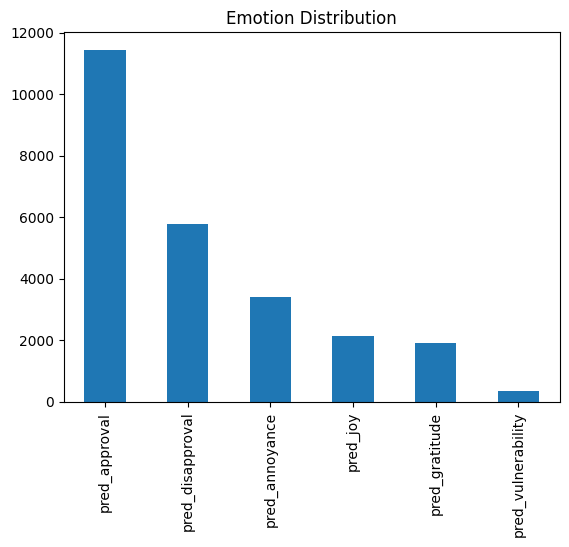

In [145]:
emotion_cols = [
    'pred_annoyance','pred_approval','pred_disapproval',
    'pred_gratitude','pred_joy','pred_vulnerability'
]

emotion_counts = untag_review[emotion_cols].sum().sort_values(ascending=False)

emotion_counts.plot(kind='bar', title="Emotion Distribution")

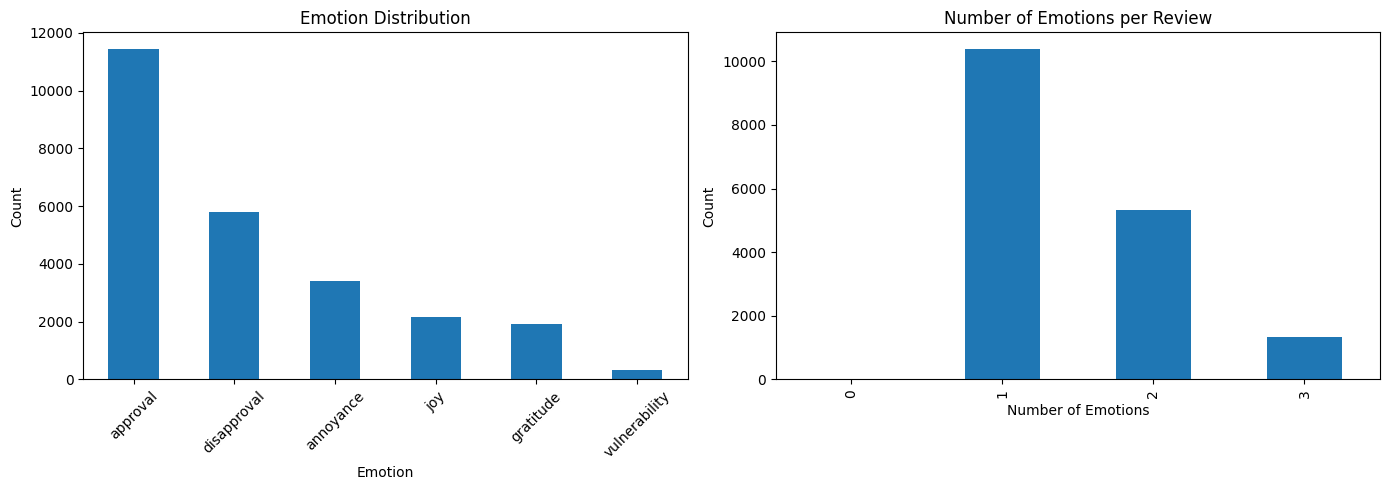

In [146]:
emotion_cols = [
    'pred_annoyance','pred_approval','pred_disapproval',
    'pred_gratitude','pred_joy','pred_vulnerability'
]

emotion_counts = untag_review[emotion_cols].sum().sort_values(ascending=False)

untag_review['num_emotions'] = untag_review[emotion_cols].sum(axis=1)
num_emotions_counts = untag_review['num_emotions'].value_counts().sort_index()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emotion_counts.index = emotion_counts.index.str.replace('pred_', '')

emotion_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title("Emotion Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

num_emotions_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title("Number of Emotions per Review")
axes[1].set_xlabel("Number of Emotions")
axes[1].set_ylabel("Count")


plt.tight_layout()
plt.show()

In [147]:
print(num_emotions_counts)

num_emotions
0        5
1    10390
2     5329
3     1332
Name: count, dtype: int64


<Axes: title={'center': 'Average Emotion Intensity'}>

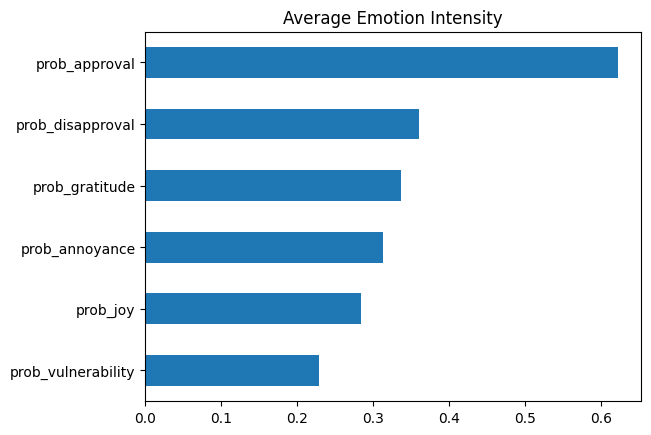

In [148]:
prob_cols = [
    'prob_annoyance','prob_approval','prob_disapproval',
    'prob_gratitude','prob_joy','prob_vulnerability'
]

untag_review[prob_cols].mean().sort_values().plot(kind='barh', title="Average Emotion Intensity")

<Axes: title={'center': 'Number of Emotions per Review'}, xlabel='num_emotions'>

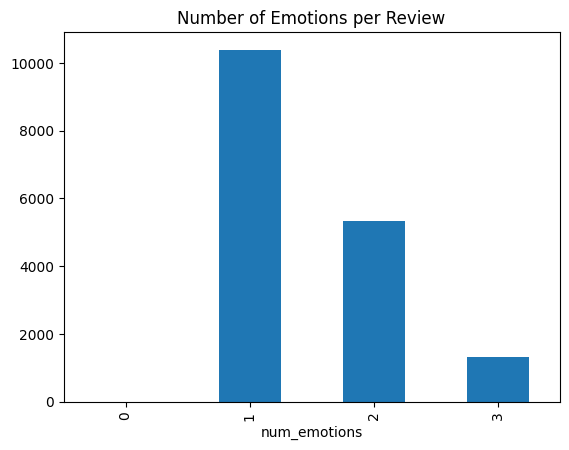

In [149]:
untag_review['num_emotions'] = untag_review[[
    'pred_annoyance','pred_approval','pred_disapproval',
    'pred_gratitude','pred_joy','pred_vulnerability'
]].sum(axis=1)

untag_review['num_emotions'].value_counts().sort_index().plot(kind='bar', title="Number of Emotions per Review")

## Emotion vs Rating

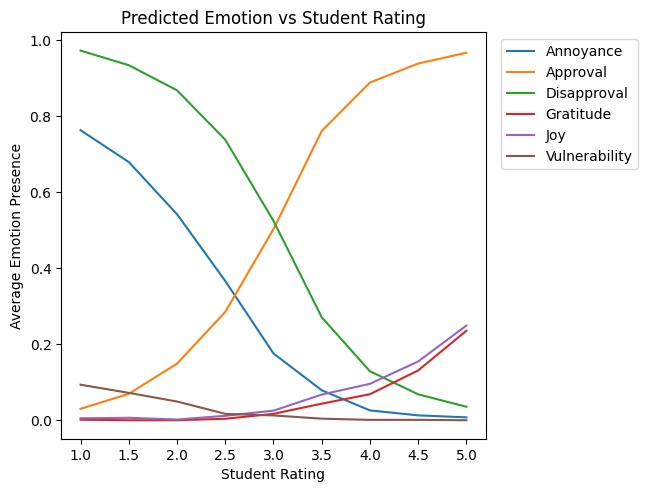

In [150]:
label_map = {
    'pred_annoyance': 'Annoyance',
    'pred_approval': 'Approval',
    'pred_disapproval': 'Disapproval',
    'pred_gratitude': 'Gratitude',
    'pred_joy': 'Joy',
    'pred_vulnerability': 'Vulnerability'
}

for emotion in emotion_cols:
    avg = untag_review.groupby('student_star')[emotion].mean()
    avg.plot(label=label_map[emotion])



plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.title("Predicted Emotion vs Student Rating")
plt.xlabel("Student Rating")
plt.ylabel("Average Emotion Presence")
plt.show()

Text(0.5, 1.0, 'Joy Distribution by Rating')

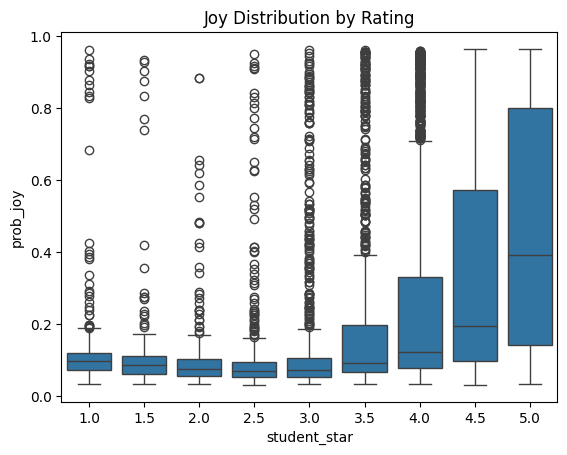

In [153]:
sns.boxplot(x='student_star', y='prob_joy', data=untag_review)
plt.title("Joy Distribution by Rating")

## Professor Features vs Emotions

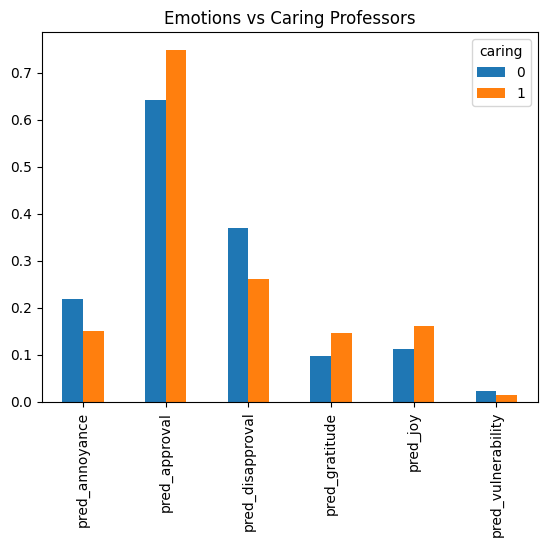

In [154]:
untag_review.groupby('caring')[emotion_cols].mean().T.plot(kind='bar')
plt.title("Emotions vs Caring Professors")
plt.show()

## Correlation Heatmap

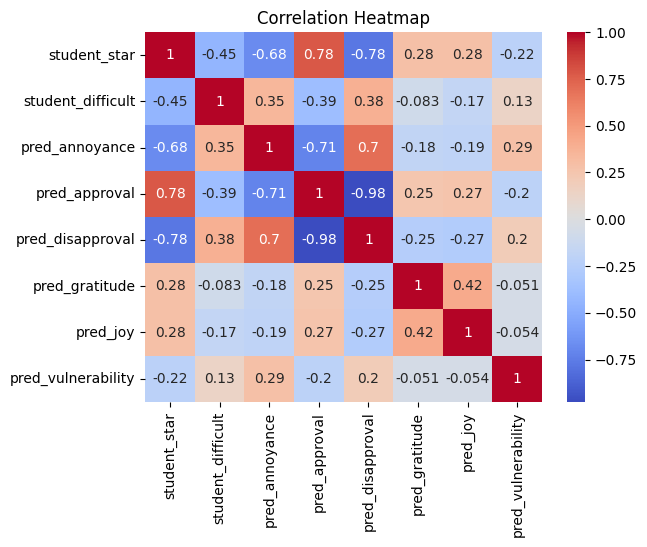

In [155]:
cols = [
    'student_star','student_difficult',
    'pred_annoyance','pred_approval','pred_disapproval',
    'pred_gratitude','pred_joy','pred_vulnerability'
]

corr = untag_review[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Tag Analysis

In [156]:
tag_cols = [
    'tough_grader','lots_of_homework','lecture_heavy',
    'test_heavy','group_projects'
]

for tag in tag_cols:
    print(f"\nTag: {tag}")
    print(untag_review.groupby(tag)['pred_annoyance'].mean())


Tag: tough_grader
tough_grader
0    0.183828
1    0.231297
Name: pred_annoyance, dtype: float64

Tag: lots_of_homework
lots_of_homework
0    0.191504
1    0.234305
Name: pred_annoyance, dtype: float64

Tag: lecture_heavy
lecture_heavy
0    0.194593
1    0.220823
Name: pred_annoyance, dtype: float64

Tag: test_heavy
test_heavy
0    0.195790
1    0.241046
Name: pred_annoyance, dtype: float64

Tag: group_projects
group_projects
0    0.198912
1    0.217270
Name: pred_annoyance, dtype: float64


In [157]:
tag_cols = ['tough_grader','lots_of_homework','group_projects','lecture_heavy']

for tag in tag_cols:
    print(f"\n{tag}")
    print(untag_review.groupby(tag)['student_star'].mean())


tough_grader
tough_grader
0    3.716136
1    3.489707
Name: student_star, dtype: float64

lots_of_homework
lots_of_homework
0    3.676453
1    3.486967
Name: student_star, dtype: float64

group_projects
group_projects
0    3.639853
1    3.603760
Name: student_star, dtype: float64

lecture_heavy
lecture_heavy
0    3.672355
1    3.513375
Name: student_star, dtype: float64


## Binary Variables analysis

In [161]:
binary_cols = [
    'gives_good_feedback','caring','respected','participation_matters',
    'clear_grading_criteria','amazing_lectures','inspirational',
    'tough_grader','hilarious','get_ready_to_read','lots_of_homework',
    'accessible_outside_class','lecture_heavy','extra_credit',
    'graded_by_few_things','group_projects','test_heavy',
    'so_many_papers','beware_of_pop_quizzes','IsCourseOnline'
]

Text(0.5, 1.0, 'Joy Distribution: Caring vs Not Caring')

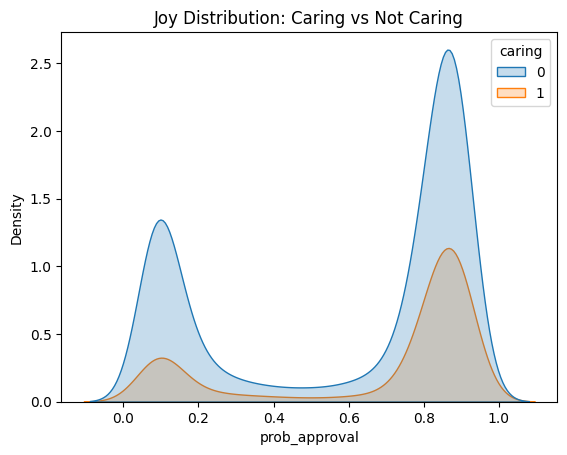

In [162]:
sns.kdeplot(data=untag_review, x='prob_approval', hue='caring', fill=True)
plt.title("Joy Distribution: Caring vs Not Caring")

Text(0.5, 1.0, 'Joy: Tough Grader vs Caring')

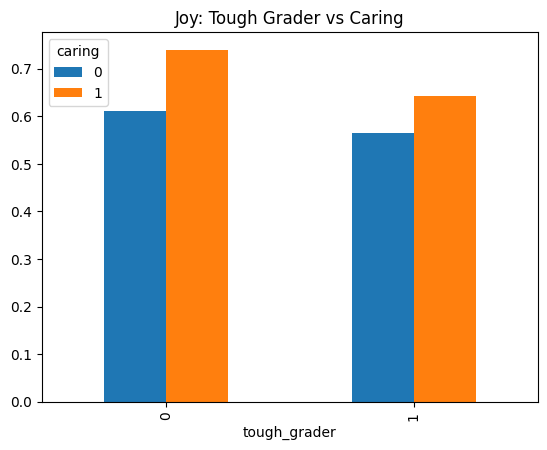

In [163]:
combo = untag_review.groupby(['tough_grader','caring'])['prob_approval'].mean().unstack()

combo.plot(kind='bar')
plt.title("Joy: Tough Grader vs Caring")

<Axes: title={'center': 'Odds Ratio for Joy'}>

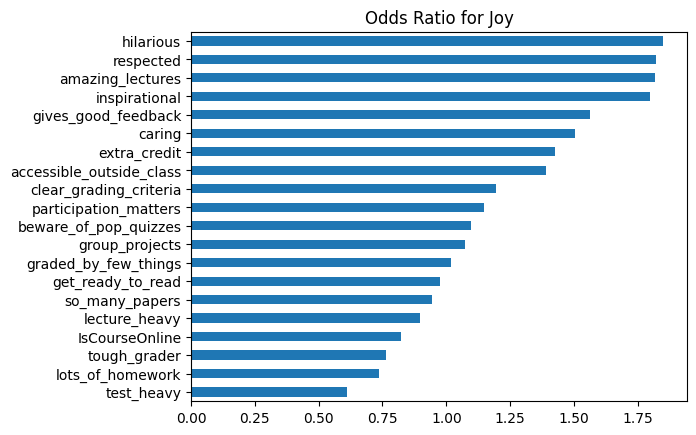

In [164]:
def odds_ratio(df, col, target):
    a = len(df[(df[col]==1) & (df[target]==1)])
    b = len(df[(df[col]==1) & (df[target]==0)])
    c = len(df[(df[col]==0) & (df[target]==1)])
    d = len(df[(df[col]==0) & (df[target]==0)])

    return (a/b) / (c/d)

odds = {}

for col in binary_cols:
    odds[col] = odds_ratio(untag_review, col, 'pred_joy')

pd.Series(odds).sort_values().plot(kind='barh', title="Odds Ratio for Joy")

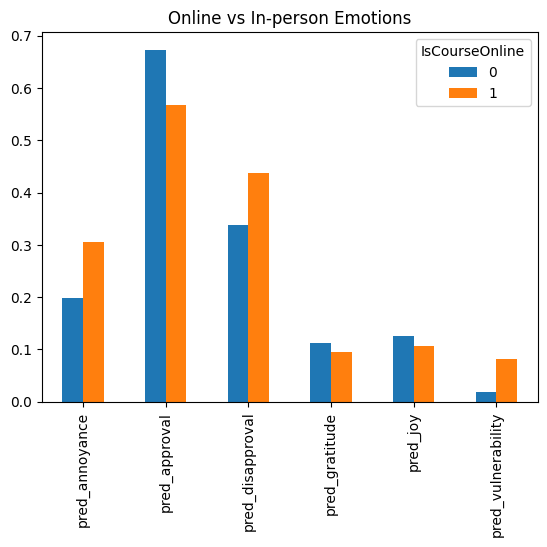

In [165]:
untag_review.groupby('IsCourseOnline')[emotion_cols].mean().T.plot(kind='bar')
plt.title("Online vs In-person Emotions")
plt.show()

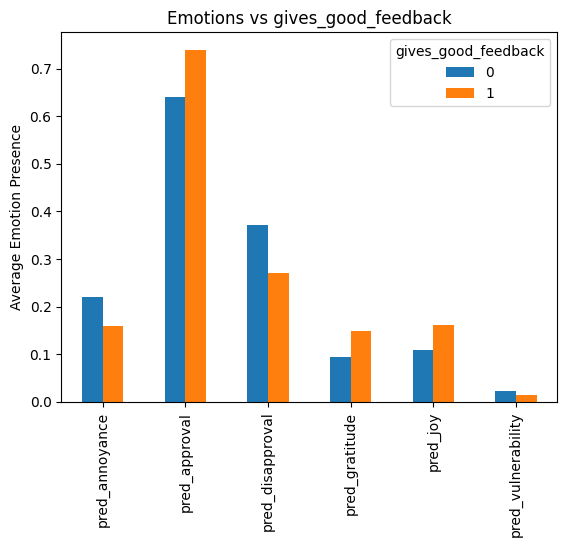

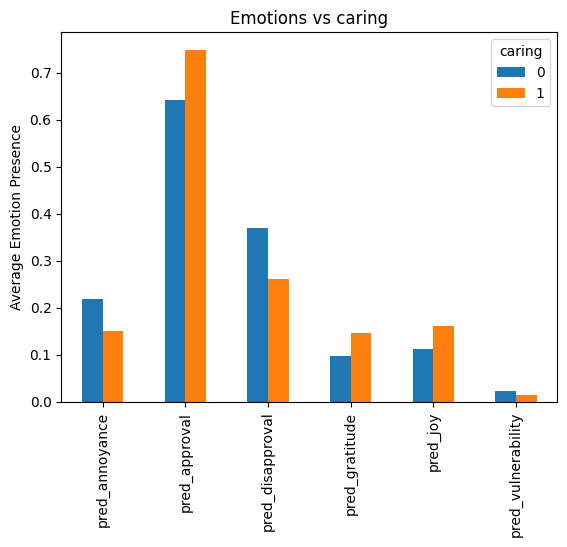

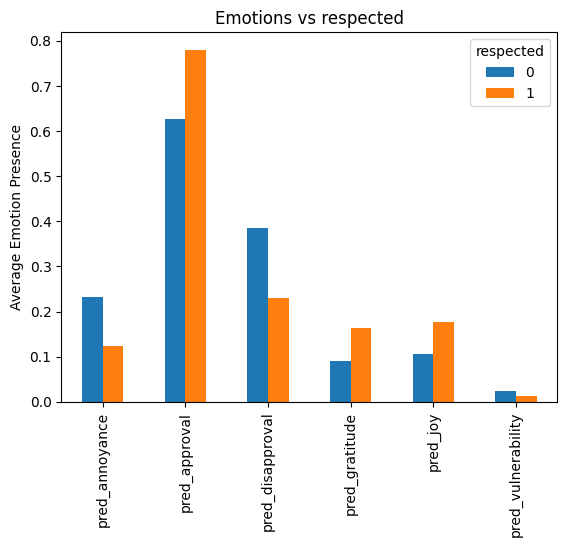

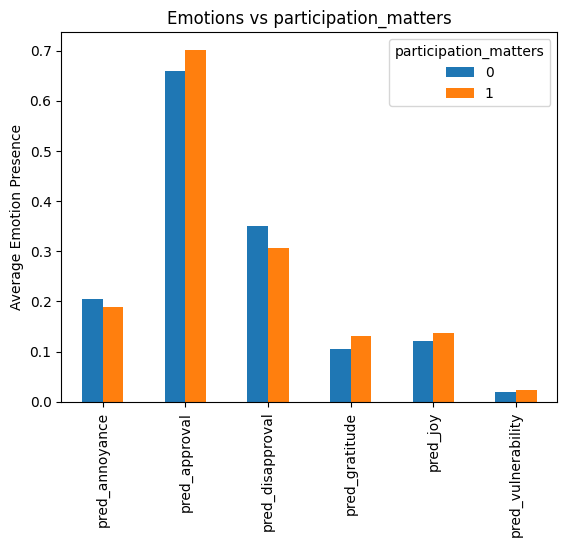

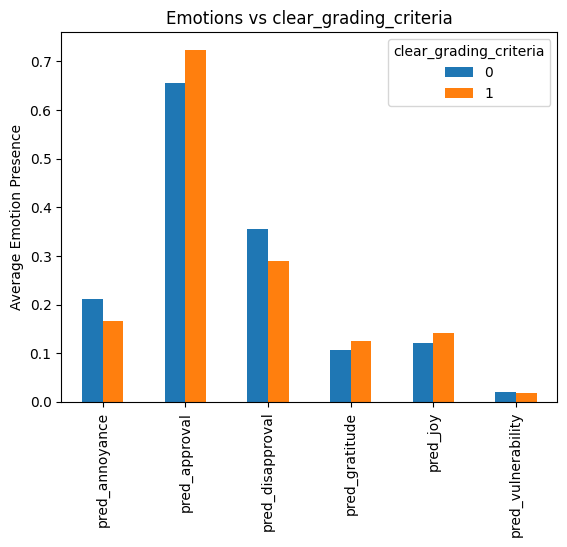

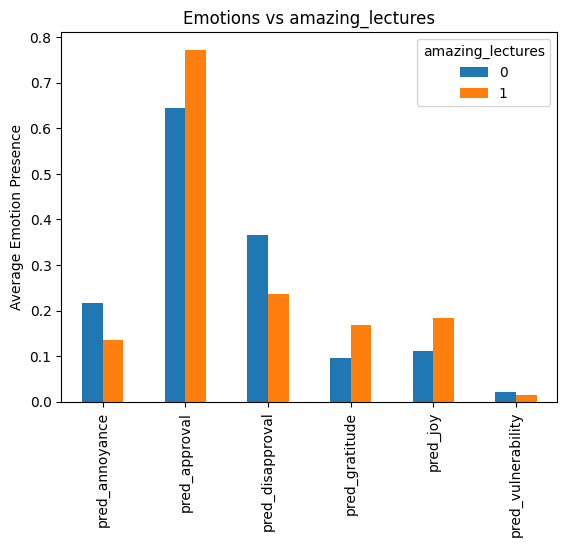

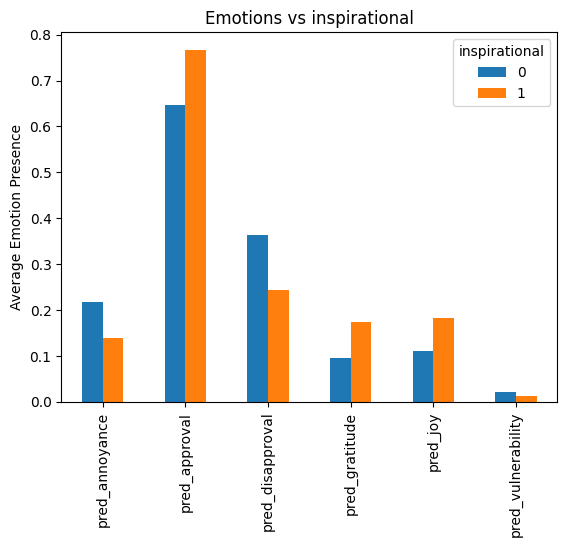

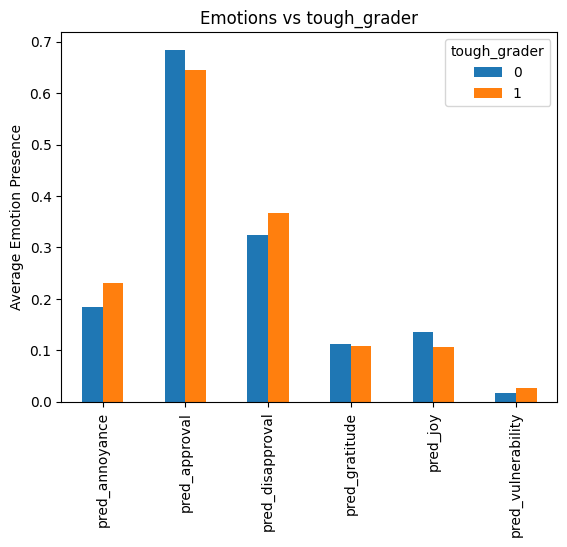

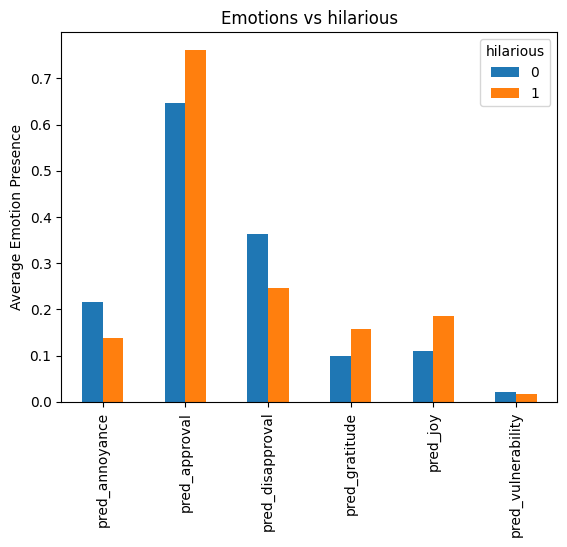

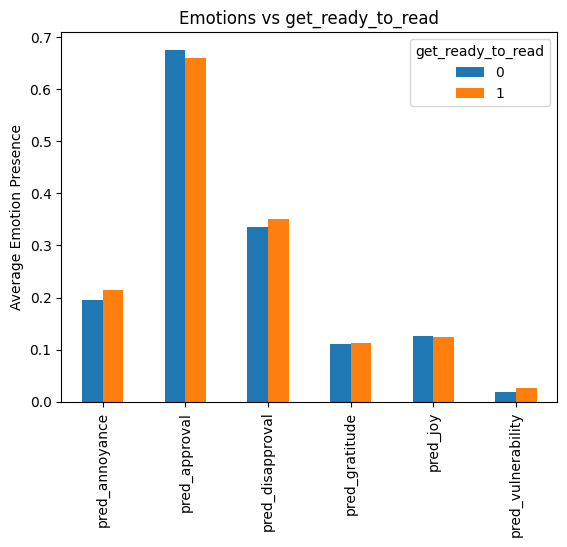

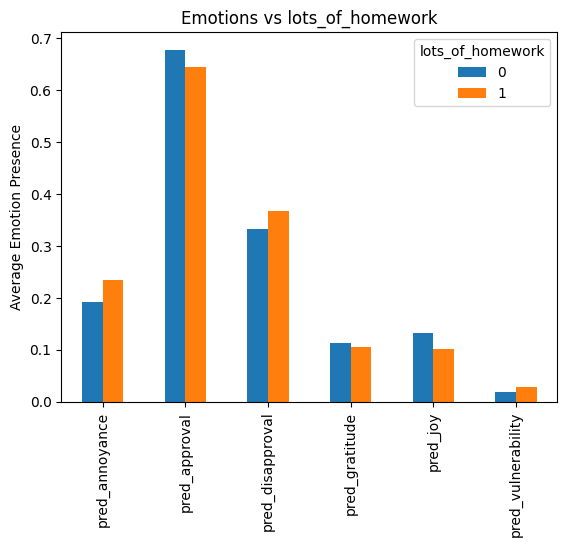

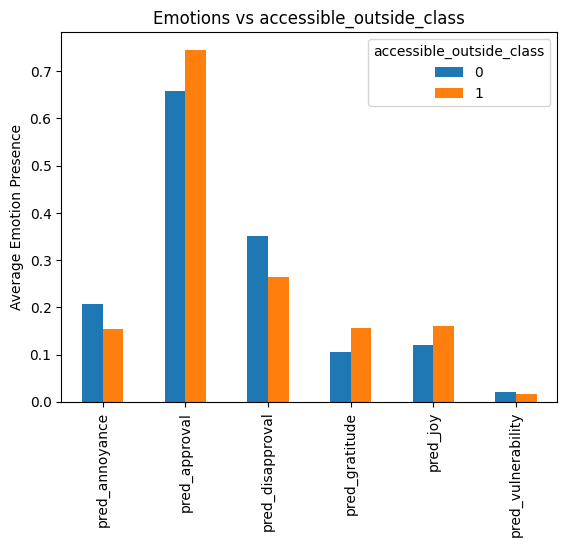

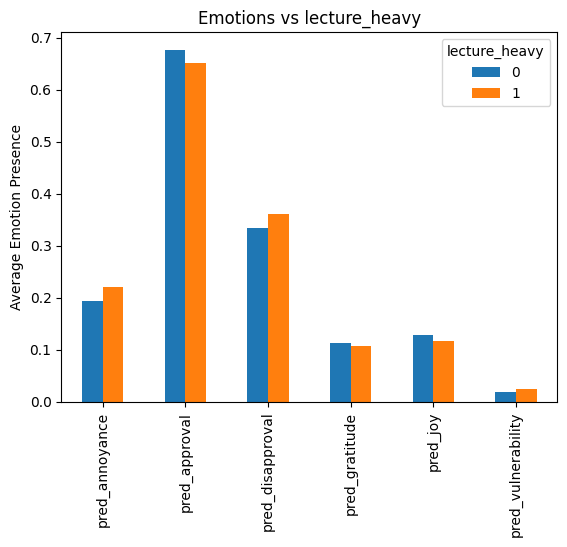

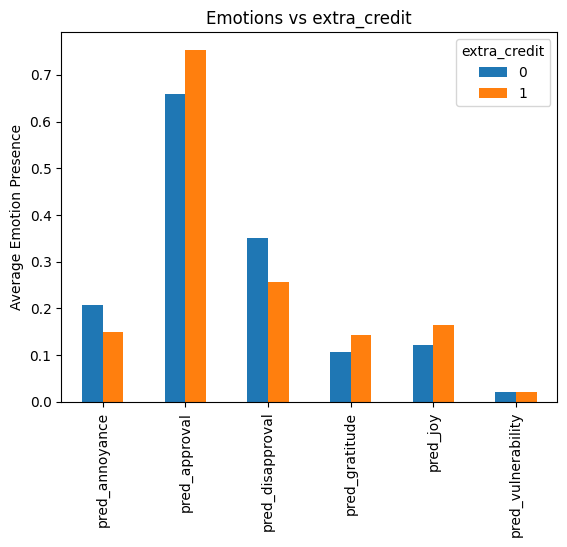

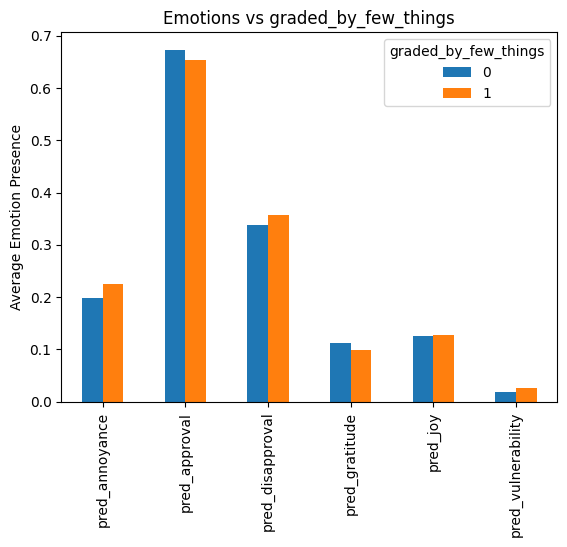

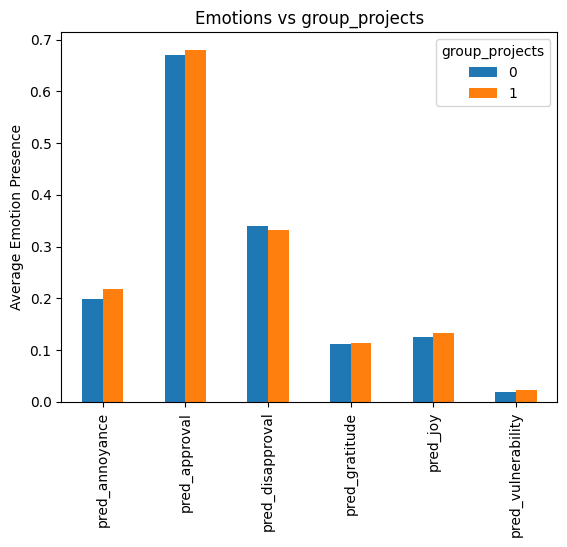

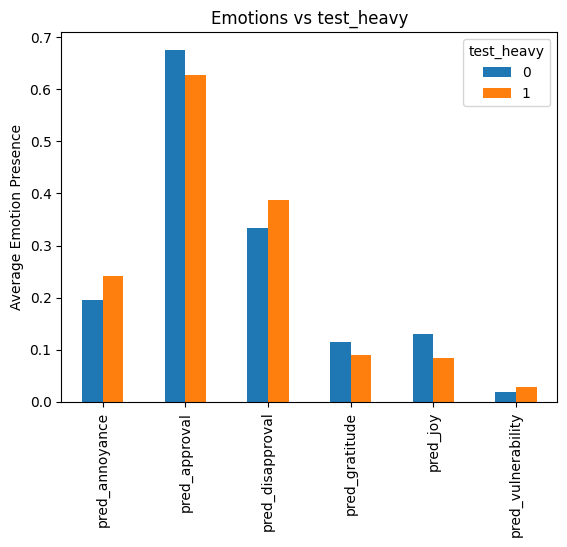

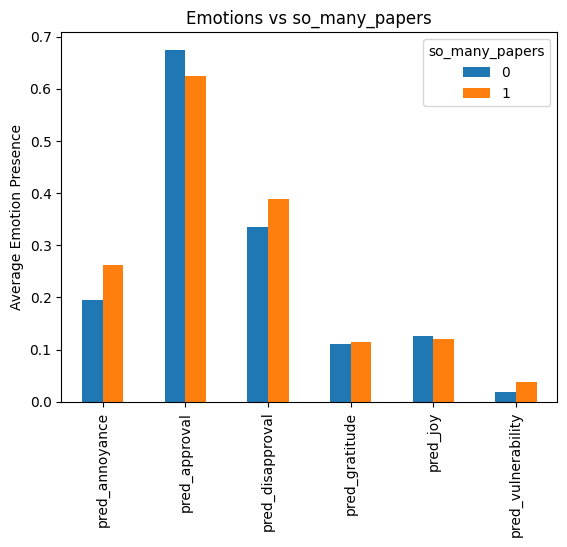

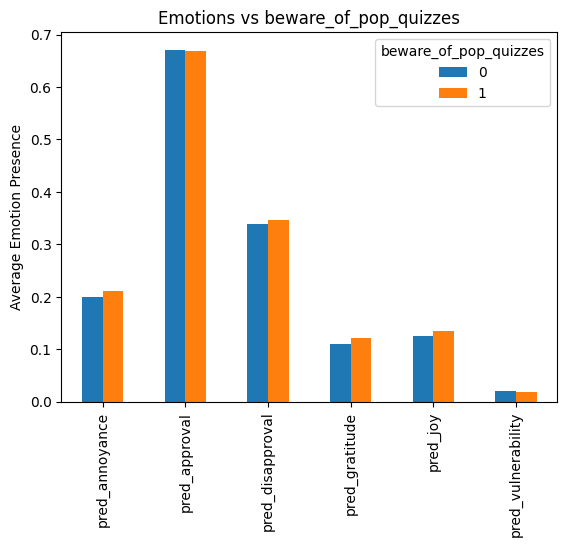

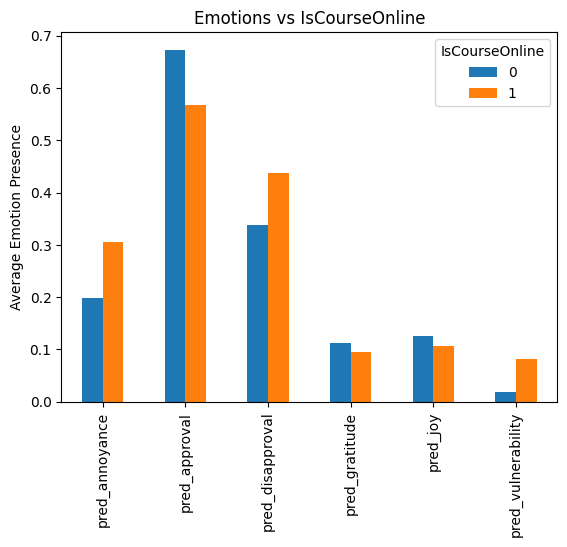

In [166]:
for col in binary_cols:
    untag_review.groupby(col)[emotion_cols].mean().T.plot(kind='bar')
    plt.title(f"Emotions vs {col}")
    plt.ylabel("Average Emotion Presence")
    plt.show()

In [167]:
# Joy Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_joy'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.11 → 0.16
caring: 0.11 → 0.16
respected: 0.11 → 0.18
participation_matters: 0.12 → 0.14
clear_grading_criteria: 0.12 → 0.14
amazing_lectures: 0.11 → 0.18
inspirational: 0.11 → 0.18
tough_grader: 0.14 → 0.11
hilarious: 0.11 → 0.19
get_ready_to_read: 0.13 → 0.12
lots_of_homework: 0.13 → 0.10
accessible_outside_class: 0.12 → 0.16
lecture_heavy: 0.13 → 0.12
extra_credit: 0.12 → 0.16
graded_by_few_things: 0.13 → 0.13
group_projects: 0.13 → 0.13
test_heavy: 0.13 → 0.08
so_many_papers: 0.13 → 0.12
beware_of_pop_quizzes: 0.13 → 0.14
IsCourseOnline: 0.13 → 0.11


<Axes: title={'center': 'Impact on Joy'}>

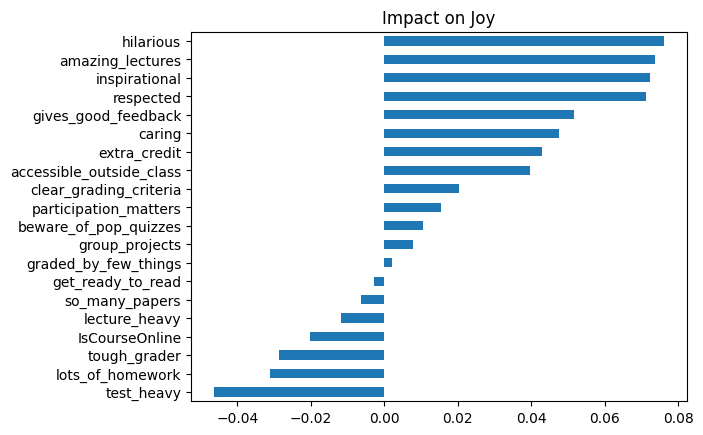

In [168]:
joy_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_joy'].mean()
    if 0 in group.index and 1 in group.index:
        joy_lift[col] = group[1] - group[0]

pd.Series(joy_lift).sort_values().plot(kind='barh', title="Impact on Joy")

In [169]:
# annoyance Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_annoyance'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.22 → 0.16
caring: 0.22 → 0.15
respected: 0.23 → 0.12
participation_matters: 0.20 → 0.19
clear_grading_criteria: 0.21 → 0.17
amazing_lectures: 0.22 → 0.14
inspirational: 0.22 → 0.14
tough_grader: 0.18 → 0.23
hilarious: 0.22 → 0.14
get_ready_to_read: 0.20 → 0.21
lots_of_homework: 0.19 → 0.23
accessible_outside_class: 0.21 → 0.15
lecture_heavy: 0.19 → 0.22
extra_credit: 0.21 → 0.15
graded_by_few_things: 0.20 → 0.22
group_projects: 0.20 → 0.22
test_heavy: 0.20 → 0.24
so_many_papers: 0.20 → 0.26
beware_of_pop_quizzes: 0.20 → 0.21
IsCourseOnline: 0.20 → 0.31


<Axes: title={'center': 'Impact on Annoyance'}>

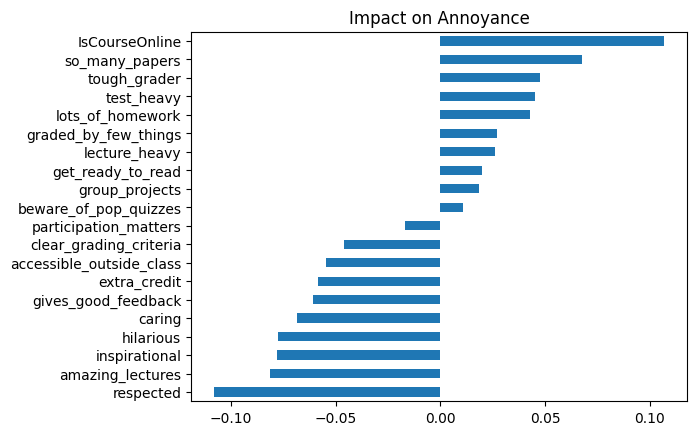

In [170]:
annoyance_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_annoyance'].mean()
    if 0 in group.index and 1 in group.index:
        annoyance_lift[col] = group[1] - group[0]

pd.Series(annoyance_lift).sort_values().plot(kind='barh', title="Impact on Annoyance")

In [171]:
# Approval Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_approval'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.64 → 0.74
caring: 0.64 → 0.75
respected: 0.63 → 0.78
participation_matters: 0.66 → 0.70
clear_grading_criteria: 0.65 → 0.72
amazing_lectures: 0.64 → 0.77
inspirational: 0.65 → 0.77
tough_grader: 0.68 → 0.65
hilarious: 0.65 → 0.76
get_ready_to_read: 0.68 → 0.66
lots_of_homework: 0.68 → 0.64
accessible_outside_class: 0.66 → 0.75
lecture_heavy: 0.68 → 0.65
extra_credit: 0.66 → 0.75
graded_by_few_things: 0.67 → 0.65
group_projects: 0.67 → 0.68
test_heavy: 0.68 → 0.63
so_many_papers: 0.67 → 0.63
beware_of_pop_quizzes: 0.67 → 0.67
IsCourseOnline: 0.67 → 0.57


<Axes: title={'center': 'Impact on Approval'}>

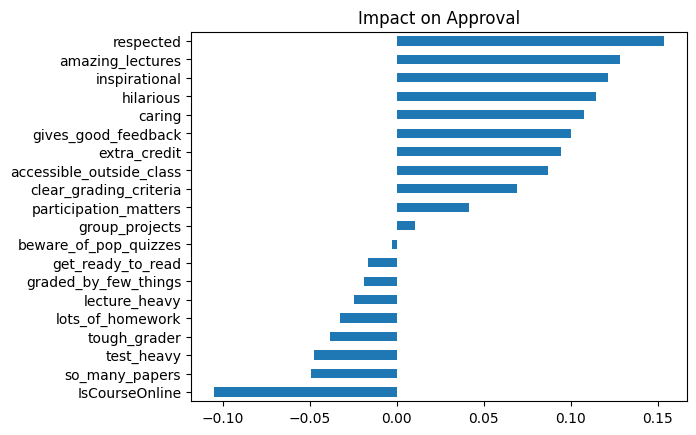

In [172]:
approval_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_approval'].mean()
    if 0 in group.index and 1 in group.index:
        approval_lift[col] = group[1] - group[0]

pd.Series(approval_lift).sort_values().plot(kind='barh', title="Impact on Approval")

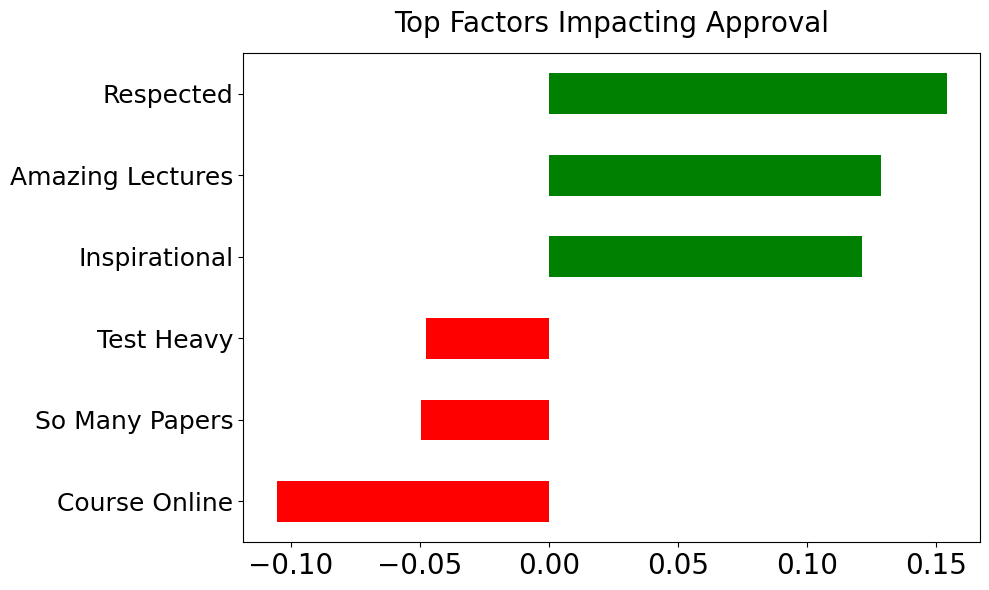

In [173]:
binary_label_map = {
    'gives_good_feedback': 'Gives Good Feedback',
    'caring': 'Caring',
    'respected': 'Respected',
    'participation_matters': 'Participation Matters',
    'clear_grading_criteria': 'Clear Grading Criteria',
    'amazing_lectures': 'Amazing Lectures',
    'inspirational': 'Inspirational',
    'tough_grader': 'Tough Grader',
    'hilarious': 'Hilarious',
    'get_ready_to_read': 'Get Ready to Read',
    'lots_of_homework': 'Lots of Homework',
    'accessible_outside_class': 'Accessible Outside Class',
    'lecture_heavy': 'Lecture Heavy',
    'extra_credit': 'Extra Credit',
    'graded_by_few_things': 'Graded by Few Things',
    'group_projects': 'Group Projects',
    'test_heavy': 'Test Heavy',
    'so_many_papers': 'So Many Papers',
    'beware_of_pop_quizzes': 'Beware of Pop Quizzes',
    'IsCourseOnline': 'Course Online'
}

impact_series = pd.Series(approval_lift).sort_values()
top_neg = impact_series.head(3)
top_pos = impact_series.tail(3)
plot_data = pd.concat([top_neg, top_pos])

# Apply labels to index
plot_data.index = plot_data.index.map(binary_label_map)

# Plot
plt.figure(figsize=(10, 6))

plot_data.plot(
    kind='barh',
    color=['red' if x < 0 else 'green' for x in plot_data]
)

plt.title("Top Factors Impacting Approval", fontsize=20, pad=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

In [174]:
# Disapproval Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_disapproval'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.37 → 0.27
caring: 0.37 → 0.26
respected: 0.38 → 0.23
participation_matters: 0.35 → 0.31
clear_grading_criteria: 0.35 → 0.29
amazing_lectures: 0.37 → 0.24
inspirational: 0.36 → 0.24
tough_grader: 0.32 → 0.37
hilarious: 0.36 → 0.25
get_ready_to_read: 0.34 → 0.35
lots_of_homework: 0.33 → 0.37
accessible_outside_class: 0.35 → 0.26
lecture_heavy: 0.33 → 0.36
extra_credit: 0.35 → 0.26
graded_by_few_things: 0.34 → 0.36
group_projects: 0.34 → 0.33
test_heavy: 0.33 → 0.39
so_many_papers: 0.34 → 0.39
beware_of_pop_quizzes: 0.34 → 0.35
IsCourseOnline: 0.34 → 0.44


<Axes: title={'center': 'Impact on Disapproval'}>

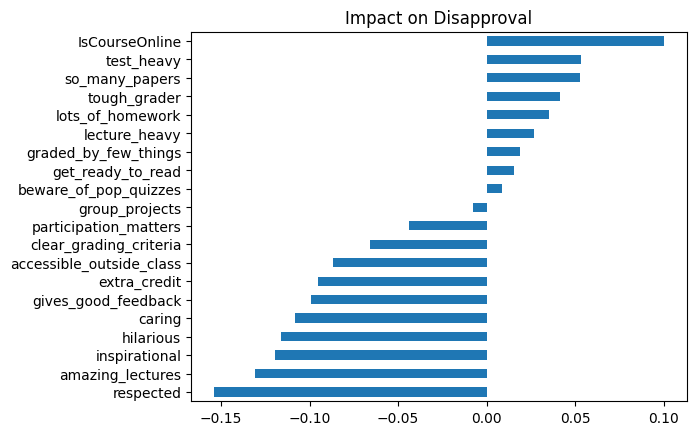

In [175]:
disapproval_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_disapproval'].mean()
    if 0 in group.index and 1 in group.index:
        disapproval_lift[col] = group[1] - group[0]

pd.Series(disapproval_lift).sort_values().plot(kind='barh', title="Impact on Disapproval")

In [176]:
# Gratitude Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_gratitude'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.09 → 0.15
caring: 0.10 → 0.15
respected: 0.09 → 0.16
participation_matters: 0.10 → 0.13
clear_grading_criteria: 0.11 → 0.13
amazing_lectures: 0.10 → 0.17
inspirational: 0.10 → 0.17
tough_grader: 0.11 → 0.11
hilarious: 0.10 → 0.16
get_ready_to_read: 0.11 → 0.11
lots_of_homework: 0.11 → 0.10
accessible_outside_class: 0.10 → 0.16
lecture_heavy: 0.11 → 0.11
extra_credit: 0.11 → 0.14
graded_by_few_things: 0.11 → 0.10
group_projects: 0.11 → 0.11
test_heavy: 0.11 → 0.09
so_many_papers: 0.11 → 0.11
beware_of_pop_quizzes: 0.11 → 0.12
IsCourseOnline: 0.11 → 0.10


<Axes: title={'center': 'Impact on Gratitude'}>

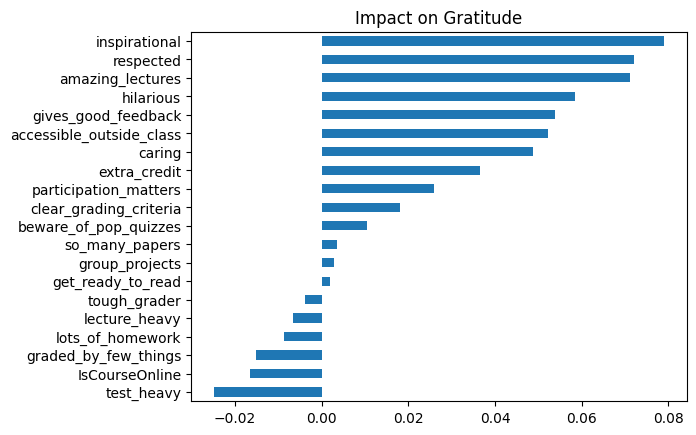

In [177]:
gratitude_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_gratitude'].mean()
    if 0 in group.index and 1 in group.index:
        gratitude_lift[col] = group[1] - group[0]

pd.Series(gratitude_lift).sort_values().plot(kind='barh', title="Impact on Gratitude")

In [178]:
# Vulnerability Analisis
for col in binary_cols:
    rate = untag_review.groupby(col)['pred_vulnerability'].mean()
    print(f"{col}: {rate[0]:.2f} → {rate[1]:.2f}")

gives_good_feedback: 0.02 → 0.02
caring: 0.02 → 0.01
respected: 0.02 → 0.01
participation_matters: 0.02 → 0.02
clear_grading_criteria: 0.02 → 0.02
amazing_lectures: 0.02 → 0.02
inspirational: 0.02 → 0.01
tough_grader: 0.02 → 0.03
hilarious: 0.02 → 0.02
get_ready_to_read: 0.02 → 0.03
lots_of_homework: 0.02 → 0.03
accessible_outside_class: 0.02 → 0.02
lecture_heavy: 0.02 → 0.02
extra_credit: 0.02 → 0.02
graded_by_few_things: 0.02 → 0.03
group_projects: 0.02 → 0.02
test_heavy: 0.02 → 0.03
so_many_papers: 0.02 → 0.04
beware_of_pop_quizzes: 0.02 → 0.02
IsCourseOnline: 0.02 → 0.08


<Axes: title={'center': 'Impact on Vulnerability'}>

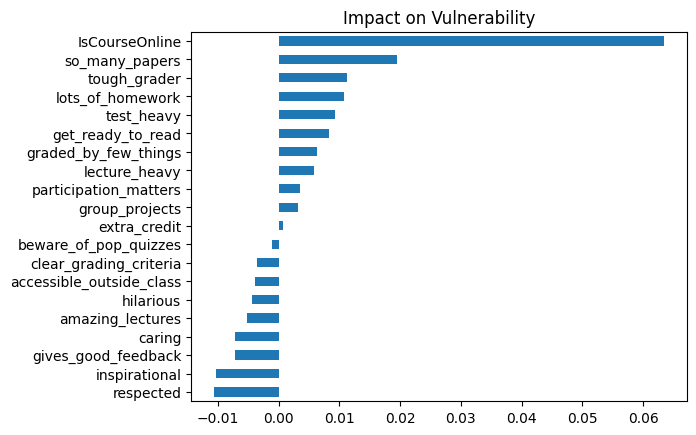

In [179]:
vulnerability_lift = {}

for col in binary_cols:
    group = untag_review.groupby(col)['pred_vulnerability'].mean()
    if 0 in group.index and 1 in group.index:
        vulnerability_lift[col] = group[1] - group[0]

pd.Series(vulnerability_lift).sort_values().plot(kind='barh', title="Impact on Vulnerability")

## Top Professors by Emotion also departments

<Axes: title={'center': 'Top Departments by Joy'}, xlabel='department_name'>

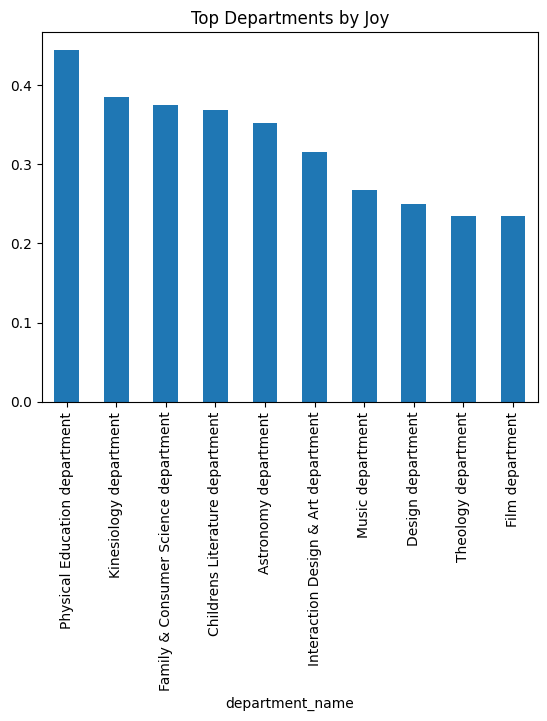

In [180]:
dept_joy = untag_review.groupby('department_name')['pred_joy'].mean().sort_values(ascending=False)

dept_joy.head(10).plot(kind='bar', title="Top Departments by Joy")

## Interesting Results

Even high-rated professors generate annoyance — possibly due to workload

In [181]:
untag_review[
    (untag_review['student_star'] >= 4) &
    (untag_review['pred_annoyance'] == 1)
]

,professor_name,department_name,num_student,student_star,student_difficult,comments,race,gives_good_feedback,caring,respected,...,prob_disapproval,pred_gratitude,prob_gratitude,pred_joy,prob_joy,pred_vulnerability,prob_vulnerability,no_emotion_predicted,predicted_emotions,num_emotions
39,Robert Warden,Writing department,8,4.5,2,the lectures are sleep-inducing unless u parti...,nh_white,0,0,0,...,0.9478,0,0.0801,0,0.0887,0,0.7867,0,"annoyance, disapproval",2
203,Ann Lewald,English department,20,4.5,1,she is the most boring teacher i never had bef...,hispanic,0,0,0,...,0.9409,0,0.1061,0,0.1283,0,0.8057,0,"annoyance, disapproval",2
207,Ann Lewald,English department,20,4.5,2,shes boring and comments on the same thing ove...,hispanic,0,0,0,...,0.9444,0,0.0844,0,0.0957,0,0.7030,0,"annoyance, disapproval",2
282,Sally Mallory,Chemistry department,3,4.0,4,orgo lab takes alot of time. just a credit and...,nh_white,0,0,0,...,0.9019,0,0.0663,0,0.0643,0,0.6661,0,"annoyance, disapproval",2
388,Dana Baylard,English department,19,4.5,3,she is awsome! you shouldn\'t go wrong with th...,hispanic,0,0,0,...,0.9351,0,0.0691,0,0.0690,0,0.5753,0,"annoyance, disapproval",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16420,Richard O\'Brien,English department,50,5.0,1,no text book needed. so you save $ whoo the on...,nh_white,0,1,1,...,0.9177,0,0.0841,0,0.0843,0,0.6670,0,"annoyance, disapproval",2
16523,Les Boggess,Criminal Justice department,45,5.0,1,awesome teacher!!!!~ his study guides are lite...,nh_white,0,0,0,...,0.9339,0,0.0949,0,0.1293,0,0.6588,0,"annoyance, disapproval",2
16528,Les Boggess,Criminal Justice department,45,5.0,1,his classes are extremely boring! we plays ent...,nh_white,0,0,0,...,0.9508,0,0.0763,0,0.0928,0,0.7177,0,"annoyance, disapproval",2
16690,James Muckell,Accounting department,16,5.0,3,mr. muckell rocks at being a yank and at all o...,nh_white,0,1,0,...,0.8958,0,0.1149,0,0.0829,0,0.4843,0,"annoyance, disapproval",2


In [182]:
untag_review[
    (untag_review['caring']==1) &
    (untag_review['pred_annoyance']==1)
]

,professor_name,department_name,num_student,student_star,student_difficult,comments,race,gives_good_feedback,caring,respected,...,prob_disapproval,pred_gratitude,prob_gratitude,pred_joy,prob_joy,pred_vulnerability,prob_vulnerability,no_emotion_predicted,predicted_emotions,num_emotions
97,Deborah Pluss,Communication department,20,1.5,4,professor pluss grades assignments very harshl...,nh_white,0,1,0,...,0.9149,0,0.0573,0,0.0580,0,0.5268,0,"annoyance, disapproval",2
162,Pat Ledbetter,History department,32,3.0,5,the most time consuming class i\'ve ever taken...,hispanic,1,1,1,...,0.9405,0,0.0860,0,0.0829,0,0.8086,0,"annoyance, disapproval",2
169,Pat Ledbetter,History department,32,2.0,4,extremely opinionated and grades papers based ...,hispanic,1,1,1,...,0.9543,0,0.1120,0,0.1120,0,0.7803,0,"annoyance, disapproval",2
175,Pat Ledbetter,History department,32,1.0,5,do yourself a favor and do not take this class...,hispanic,1,1,1,...,0.9442,0,0.1073,0,0.1119,0,0.7954,0,"annoyance, disapproval",2
177,Pat Ledbetter,History department,32,3.0,4,class is intense! omg i had to work my butt of...,hispanic,1,1,1,...,0.9212,0,0.1251,0,0.1325,0,0.8467,0,"annoyance, disapproval",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16981,Brian Potter,English department,65,3.0,4,"online classes have always been tricky, and in...",hispanic,1,1,1,...,0.9212,0,0.0811,0,0.0642,0,0.7641,0,"annoyance, disapproval",2
16982,Brian Potter,English department,65,1.0,4,"professor potter was impersonal, was weeks/ mo...",hispanic,1,1,1,...,0.9467,0,0.1074,0,0.0932,0,0.8152,0,"annoyance, disapproval",2
17002,Joseph Sierra,Film department,114,1.5,4,i wanted to take foster but ended up taking si...,hispanic,1,1,1,...,0.9519,0,0.1234,0,0.1309,0,0.8090,0,"annoyance, disapproval",2
17014,Joseph Sierra,Film department,114,4.5,1,ridiculously easy class. he tells you what wil...,hispanic,1,1,1,...,0.9409,0,0.0731,0,0.0715,0,0.6529,0,"annoyance, disapproval",2


In [183]:
X = untag_review[prob_cols]

kmeans = KMeans(n_clusters=3, random_state=42)
untag_review['cluster'] = kmeans.fit_predict(X)

untag_review.groupby('cluster')[prob_cols].mean()

,prob_annoyance,prob_approval,prob_disapproval,prob_gratitude,prob_joy,prob_vulnerability
cluster,,,,,,
0,0.084611,0.868067,0.063824,0.738947,0.722448,0.061965
1,0.802712,0.135497,0.903685,0.089220,0.084896,0.615880
2,0.108318,0.813190,0.158347,0.256063,0.145502,0.057365


In [184]:
untag_review.groupby('cluster')['student_star'].mean()

,student_star
cluster,
0,4.699935
1,1.936586
2,4.178705


<Axes: title={'center': 'Drivers of Student Rating'}>

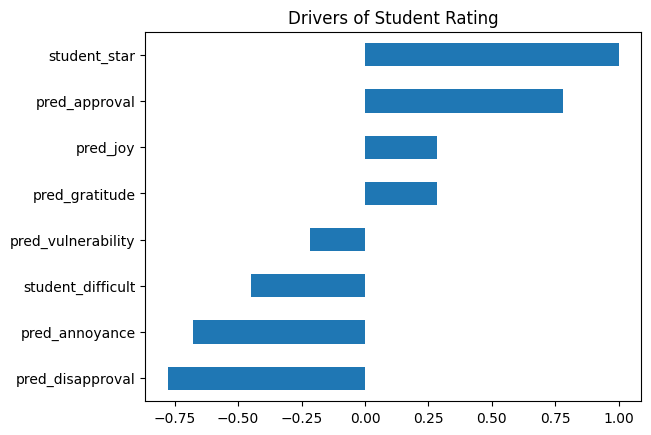

In [185]:
corr = untag_review[[
    'student_star',
    'student_difficult',
    'pred_joy','pred_annoyance','pred_gratitude','pred_disapproval', 'pred_approval',  'pred_vulnerability'
]].corr()['student_star'].sort_values()

corr.plot(kind='barh', title="Drivers of Student Rating")